<a href="https://colab.research.google.com/github/sathwikapathi/Thesisguard/blob/main/dl_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y scikit-learn scikeras
!pip install -q scikit-learn==1.5.2 scikeras

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
import numpy as np
#Activation function
def sigmoid(x):
    return 1/(1+np.exp(-x))
def relu(x):
    return np.maximum(0,x)
#neuron function
def neuron(x,weight,bias):
    z = np.dot(x,weight) + bias
    return sigmoid(z)
def hidden_to_hidden(x,weight,bias):
    z = np.dot(x,weight) + bias
    print("hidden layer linear output(z):",z)
    activated = relu(z)
    print("hidden layer activation(ReLu):",activated)
    return activated
def hidden_to_output(hidden_activations,weight,bias):
    z = np.dot(hidden_activations,weight) + bias
    print("output layer linear output(z):",z)
    activated = sigmoid(z)
    print("final output after sigmoid:",activated)
    return activated
np.random.seed(42)
x = np.array([0.5,0.2,0.1])
w1 = np.random.randn(3,4)
b1 = np.random.randn(4)
w2 = np.random.randn(4,1)
b2 = np.random.randn(1)
print("input:",x)
h = hidden_to_hidden(x,w1,b1)
output = hidden_to_output(h,w2,b2)
print("\n predicted output :",output)

input: [0.5 0.2 0.1]
hidden layer linear output(z): [ 0.39654123 -1.97498378 -1.13157277  0.30614137]
hidden layer activation(ReLu): [0.39654123 0.         0.         0.30614137]
output layer linear output(z): [0.63165488]
final output after sigmoid: [0.65286461]

 predicted output : [0.65286461]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Load and Preprocess Data
df = pd.read_csv("heart.csv")
X = df[['age', 'chol', 'thalach']].values
Y = df['target'].values

# Standardize Features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 2. Initialize Parameters
np.random.seed(42)
weights = np.random.randn(X.shape[1])
bias = 0.0
lr = 0.01

# 3. Activation & Prediction Functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(X):
    return sigmoid(np.dot(X, weights) + bias)

# 4. Training Loop
for epoch in range(100):
    preds = predict(X)
    error = preds - Y

    # Gradient Calculation
    dw = np.dot(X.T, error) / len(Y)
    db = np.mean(error)

    # Gradient Descent Update
    weights -= lr * dw
    bias -= lr * db

    # Print Loss (Now properly nested inside the loop)
    if epoch % 10 == 0:
        loss = -np.mean(Y * np.log(preds + 1e-5) + (1 - Y) * np.log(1 - preds + 1e-5))
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# 5. Evaluation
final_preds = predict(X) >= 0.5
acc = accuracy_score(Y, final_preds)
print(f"Final accuracy of single neuron model: {acc:.2f}")


Epoch 0: Loss = 0.6550
Epoch 10: Loss = 0.6511
Epoch 20: Loss = 0.6475
Epoch 30: Loss = 0.6440
Epoch 40: Loss = 0.6408
Epoch 50: Loss = 0.6378
Epoch 60: Loss = 0.6350
Epoch 70: Loss = 0.6324
Epoch 80: Loss = 0.6299
Epoch 90: Loss = 0.6276
Final accuracy of single neuron model: 0.68


In [ ]:
!wget https://raw.githubusercontent.com/foufou34/Heart_Disease_Prediction/main/heart.csv -O heart.csv
import pandas as pd

# Read the dataset
df = pd.read_csv('heart.csv')

# Display the first 5 rows
print(df.head())

--2026-07-22 06:04:58--  https://raw.githubusercontent.com/foufou34/Heart_Disease_Prediction/main/heart.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-22 06:04:58 ERROR 404: Not Found.



EmptyDataError: No columns to parse from file

### Binary Classification with `processed.cleveland.data`

Since we had trouble downloading the `heart.csv` file, I will proceed with your request to provide sample code for binary classification using the `processed.cleveland.data` file from the UCI Machine Learning Repository.

In [ ]:
# Download the 'processed.cleveland.data' file
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data -O processed.cleveland.data

--2026-07-22 06:04:59--  https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘processed.cleveland.data’

processed.cleveland     [ <=>                ]  18.03K   107KB/s    in 0.2s    

2026-07-22 06:05:01 (107 KB/s) - ‘processed.cleveland.data’ saved [18461]



The `processed.cleveland.data` file does not come with headers, so we need to define them. We'll also handle missing values and prepare the data for modeling.

In [ ]:
import pandas as pd
import numpy as np

# Define column names as per UCI dataset documentation
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the dataset, specifying no header
df_cleveland = pd.read_csv('processed.cleveland.data', names=columns)

# Replace '?' with NaN for missing values
df_cleveland = df_cleveland.replace('?', np.nan)

# Convert columns 'ca' and 'thal' to numeric, as they were loaded as objects due to '?'
df_cleveland['ca'] = pd.to_numeric(df_cleveland['ca'])
df_cleveland['thal'] = pd.to_numeric(df_cleveland['thal'])

# Drop rows with any missing values for simplicity in this example
df_cleveland.dropna(inplace=True)

# The 'target' column has values 0, 1, 2, 3, 4. For binary classification,
# we'll consider 0 as 'no disease' and anything > 0 as 'disease'.
df_cleveland['target'] = df_cleveland['target'].apply(lambda x: 1 if x > 0 else 0)

print("First 5 rows of the processed data:")
display(df_cleveland.head())

print("\nData Information:")
df_cleveland.info()

First 5 rows of the processed data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


Now we'll split the data into features (X) and target (Y), and then scale the features and split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (Y)
X = df_cleveland.drop('target', axis=1)
Y = df_cleveland['target']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42, stratify=Y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (733182890.py, line 14)

Finally, we'll train a Logistic Regression model on the processed data and evaluate its performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd

# Read the dataset
df = pd.read_csv('heart.csv')

# Display the first 5 rows
print(df.head())

EmptyDataError: No columns to parse from file

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv(r'/heart.csv')

# Select input features
X = df[['age', 'chol', 'thalach']].values
y = df['target'].values

# Normalize inputs
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Initialize weights and bias
np.random.seed(42)
weights = np.random.randn(X.shape[1])
bias = 0.0

# Learning rate
lr = 0.01


# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Prediction function
def predict(X):
    return sigmoid(np.dot(X, weights) + bias)


# Training a Single Neuron using Gradient Descent
for epoch in range(100):

    # Make predictions
    preds = predict(X)

    # Calculate error
    error = preds - y

    # Calculate gradients
    dw = np.dot(X.T, error) / len(y)
    db = np.mean(error)

    # Update weights and bias
    weights -= lr * dw
    bias -= lr * db

    # Calculate and print loss every 10 epochs
    if epoch % 10 == 0:
        loss = -np.mean(
            y * np.log(preds + 1e-5) +
            (1 - y) * np.log(1 - preds + 1e-5)
        )

        print(f"Epoch {epoch}: Loss = {loss:.4f}")


# Final Prediction and Evaluation
final_preds = predict(X) >= 0.5

acc = accuracy_score(y, final_preds)

print(f"Final Accuracy of Single Neuron Model: {acc:.2f}")

Epoch 0: Loss = 0.6550
Epoch 10: Loss = 0.6511
Epoch 20: Loss = 0.6475
Epoch 30: Loss = 0.6440
Epoch 40: Loss = 0.6408
Epoch 50: Loss = 0.6378
Epoch 60: Loss = 0.6350
Epoch 70: Loss = 0.6324
Epoch 80: Loss = 0.6299
Epoch 90: Loss = 0.6276
Final Accuracy of Single Neuron Model: 0.68


In [10]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)

2.20.0


Fetching MNIST dataset... this may take a moment.
MNIST Data Shape: (70000, 784)
MNIST Target Shape: (70000,)



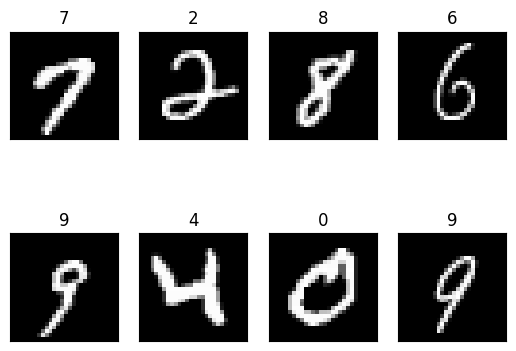

In [11]:
#week 3
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.datasets import fetch_openml

# ------------------------------------------
# 1. Loading MNIST (Moved to top to prevent errors)
# 'as_frame=False' is strictly required in modern sklearn to return arrays instead of DataFrames
# ------------------------------------------
print("Fetching MNIST dataset... this may take a moment.")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print(f"MNIST Data Shape: {mnist.data.shape}")
print(f"MNIST Target Shape: {mnist.target.shape}\n")

# ------------------------------------------
# 2. Preparing the Data (MNIST Samples)
# ------------------------------------------
for i, (img, y_label) in enumerate(zip(mnist.data[15:23].reshape(8, 28, 28), mnist.target[15:23])):
    plt.subplot(241 + i)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(y_label)
plt.savefig('ch.3.mnist_samples.png', bbox_inches='tight', dpi=350)
plt.show()

In [12]:
# 3. Binary Targets on the Cleveland Heart Disease Dataset
# ------------------------------------------
# Download the dataset directly in the cell
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

# Read dataset and handle missing values ('?' -> NaN)
df_heart = pd.read_csv('processed.cleveland.data', header=None, na_values='?')
print("Heart Disease Dataset Head:")
print(df_heart.head())

print("\nUnique target values before replacement:", set(df_heart[13].dropna()))
df_heart[13].replace(to_replace=[2, 3, 4], value=1, inplace=True)
print("Unique target values after replacement:", set(df_heart[13].dropna()), "\n")

# ------------------------------------------
# 4. Binarizing the MNIST Dataset
# ------------------------------------------
# Copy a sample to avoid permanently mutating the main dataset
sample_img = mnist.data[0].copy()
print("Original Center Pixels (10:18, 10:18):")
print(sample_img.reshape(28, 28)[10:18, 10:18])

sample_img[sample_img < 128] = 0
sample_img[sample_img >= 128] = 1
print("\nBinarized Center Pixels (10:18, 10:18):")
print(sample_img.reshape(28, 28)[10:18, 10:18], "\n")

# ------------------------------------------
# 5. Binarizing The Targets
# ------------------------------------------
X_bin = mnist.data[(mnist.target == '7') | (mnist.target == '8')]
y_bin = mnist.target[(mnist.target == '7') | (mnist.target == '8')]
print(f"Filtered X Shape: {X_bin.shape}")
print(f"Filtered y Shape: {y_bin.shape}")

print("Original Targets (first 10):", y_bin[:10])
y_bin = [0 if v == '7' else 1 for v in y_bin]
print("Binarized Targets (first 10):", y_bin[:10], "\n")

Heart Disease Dataset Head:
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0

Unique target values before replacement: {0, 1, 2, 3, 4}
Unique target values after replacement: {0, 1} 

Original Center Pixels (10:18, 10:18):
[[  1 154 253  90   0   0   0   0]
 [  0 139 253 190   2   0   0   0]
 [  0  11 190 253  70   0   0   0]
 [  0   0  35 241 225 160 108   1]
 [  0   0   0  81 240 253 253 119]
 [  0   0   0   0  45 186 253 253]
 [  0   0   0   0   0  16  93 252]
 [  0   0   0   0   0   0   0 249]]

Binarized Center Pixels (10:18, 10:18):
[[0 1 1 0 0 0 0 0]
 [0 1 1 1 0 0 0 0

/tmp/ipykernel_925/169975190.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_heart[13].replace(to_replace=[2, 3, 4], value=1, inplace=True)


Filtered X Shape: (14118, 784)
Filtered y Shape: (14118,)
Original Targets (first 10): ['7' '8' '7' '8' '7' '8' '7' '8' '7' '8']
Binarized Targets (first 10): [0, 1, 0, 1, 0, 1, 0, 1, 0, 1] 



In [13]:
# ------------------------------------------
# 6. Converting String Labels to Numbers
# ------------------------------------------
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
unique_targets = list(set(mnist.target))
print("Unique target labels:", sorted(unique_targets))
le.fit(sorted(unique_targets))

print("Classes:", list(le.classes_))
print("Transform ['9', '3', '7']:", le.transform(["9", "3", "7"]))
print("Inverse transform [2, 2, 1]:", list(le.inverse_transform([2, 2, 1])))

print("Before LE Transform:", mnist.target[:3])
y_le = le.transform(mnist.target)
print("After LE Transform:", y_le[:3], "\n")

# ------------------------------------------
# 7. Converting Categories To One Hot Encoding
# ------------------------------------------
df_gender = pd.DataFrame({'Gender': ['female', 'male', 'male', 'female', 'female']})
print(df_gender)
print(pd.get_dummies(df_gender, prefix=['Gender']))

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y_enc_input = [[v] for v in mnist.target]
enc.fit(y_enc_input)

print('\nBefore OneHot:', y_enc_input[0])
y_enc_output = enc.transform(y_enc_input).toarray()
print('After OneHot:', y_enc_output[0])
# Fix: get_feature_names() is deprecated in modern sklearn, replaced with get_feature_names_out()
print(enc.get_feature_names_out(), "\n")


# ==========================================
# REAL-VALUED DATA AND UNIVARIATE REGRESSION
# ==========================================

from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer

# We use df_heart (which we loaded with na_values='?') and drop NaNs for scaling
df_clean = df_heart.dropna().copy()

print("Original Stats (Cols 4 & 9):")
print(df_clean[[4, 9]].describe())

# Scaling to Specific Values
scaler_mm = MinMaxScaler()
df_clean[[4, 9]] = scaler_mm.fit_transform(df_clean[[4, 9]])
print("\nMinMax Scaled Stats:")
print(df_clean[[4, 9]].describe())

# Standardizing to Zero Mean and Unit Variance
df_clean = df_heart.dropna().copy()
scaler_std = StandardScaler()
df_clean[[4, 9]] = scaler_std.fit_transform(df_clean[[4, 9]])
print("\nStandard Scaled Stats:")
print(df_clean[[4, 9]].describe())

# Altering the Distribution of Data (Quantile Transformation)
df_clean = df_heart.dropna().copy()
transformer_q = QuantileTransformer(output_distribution='normal')
df_clean[[4, 9]] = transformer_q.fit_transform(df_clean[[4, 9]])
print("\nQuantile Transformed Stats:")
print(df_clean[[4, 9]].describe())

Unique target labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]
Transform ['9', '3', '7']: [9 3 7]
Inverse transform [2, 2, 1]: [np.str_('2'), np.str_('2'), np.str_('1')]
Before LE Transform: ['5' '0' '4']
After LE Transform: [5 0 4] 

   Gender
0  female
1    male
2    male
3  female
4  female
   Gender_female  Gender_male
0           True        False
1          False         True
2          False         True
3           True        False
4           True        False

Before OneHot: ['5']
After OneHot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
['x0_0' 'x0_1' 'x0_2' 'x0_3' 'x0_4' 'x0_5' 'x0_6' 'x0_7' 'x0_8' 'x0_9'] 

Original Stats (Cols 4 & 9):
                4           9
count  297.000000  297.000000
mean   247.350168    1.055556
std     51.997583    1.166123
min    126.000000    0.000000
25%    211.000000    0.000000
50%    243.000

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (297). n_quantiles is set to n_samples.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (297). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (297). n_quantiles is set to n_samples.
  warnings.warn(


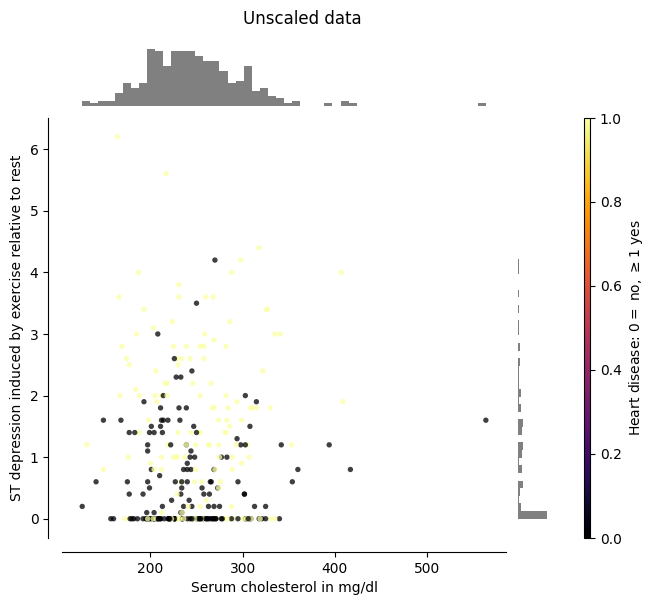

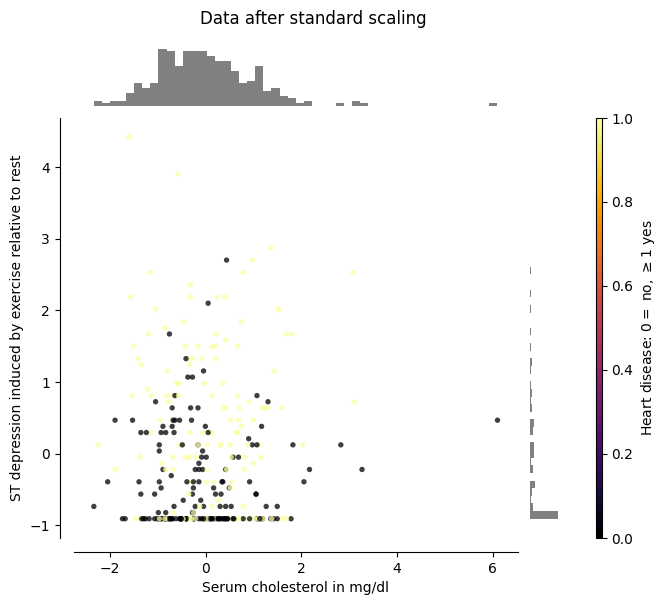

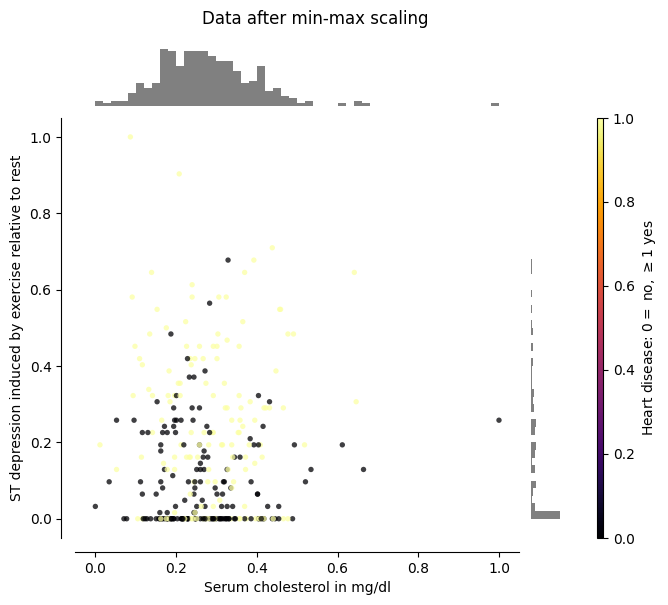

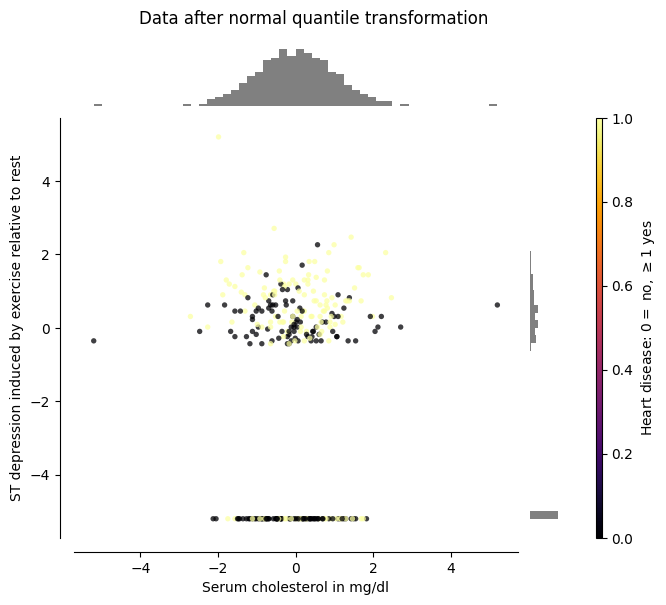

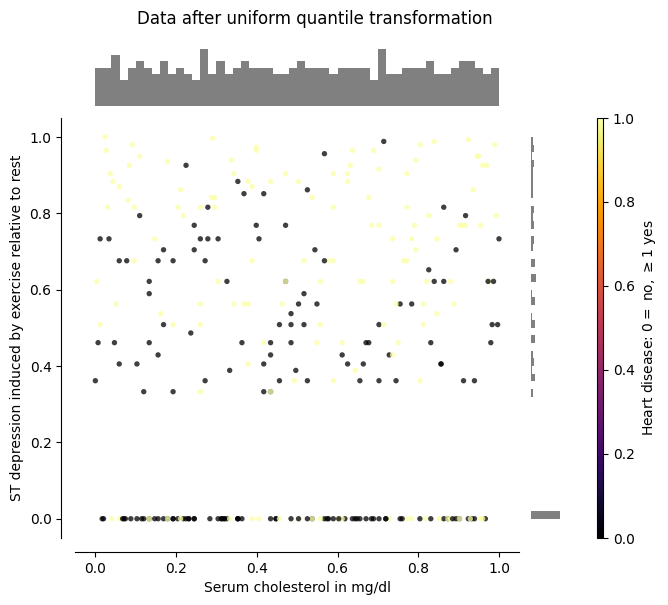

In [14]:
# ------------------------------------------
# 8. Plotting Distributions
# ------------------------------------------
X_dist = df_heart.dropna()[[4, 9]].values
y_full = df_heart.dropna()[13].values

distributions = [
    ('Unscaled data', X_dist),
    ('Data after standard scaling', StandardScaler().fit_transform(X_dist)),
    ('Data after min-max scaling', MinMaxScaler().fit_transform(X_dist)),
    ('Data after normal quantile transformation', QuantileTransformer(output_distribution='normal').fit_transform(X_dist)),
    ('Data after uniform quantile transformation', QuantileTransformer(output_distribution='uniform').fit_transform(X_dist))
]

y_dist_scaled = minmax_scale(y_full)
cmap_custom = getattr(cm, 'inferno', cm.hot_r)

def create_axes(title, figsize=(6, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    left, width = 0.1, 0.74
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.12
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    left_cb = width + left + 0.13
    rect_colorbar = [left_cb, bottom, 0.01, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return ((ax_scatter, ax_histy, ax_histx), ax_colorbar)

def plot_distribution(axes, X_val, y_val, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    colors = cmap_custom(y_val)
    ax.scatter(X_val[:, 0], X_val[:, 1], alpha=0.75, marker='o', s=15, lw=0, c=colors)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(X_val[:, 1], bins=hist_nbins, orientation='horizontal', color='grey', ec='grey')
    hist_X1.axis('off')

    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(X_val[:, 0], bins=hist_nbins, orientation='vertical', color='grey', ec='grey')
    hist_X0.axis('off')

def make_plot(item_idx):
    title, X_plot = distributions[item_idx]
    ax_zoom_out, ax_colorbar = create_axes(title)
    plot_distribution(ax_zoom_out, X_plot, y_dist_scaled, hist_nbins=50,
                      x0_label="Serum cholesterol in mg/dl",
                      x1_label="ST depression induced by exercise relative to rest")

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    # Fix: Added 'r' before string to treat as raw string to avoid \g escape warning
    mpl.colorbar.ColorbarBase(ax_colorbar, cmap=cmap_custom, norm=norm, orientation='vertical',
                              label=r'Heart disease: $0=$ no, $\geq 1$ yes')
    plt.savefig('ch.3.normalization.'+str(item_idx)+'.png', bbox_inches='tight', dpi=350)
    plt.show()

# Generate plots
for i in range(5):
    make_plot(i)

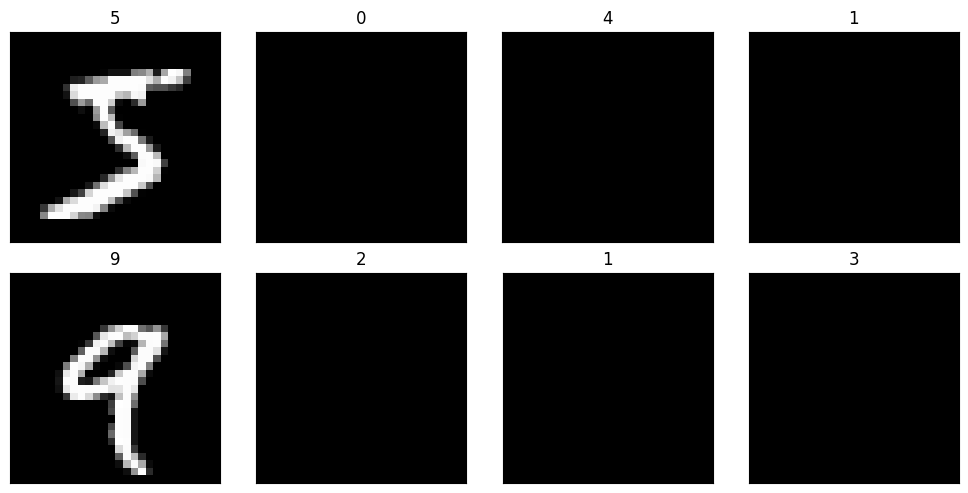

In [15]:
# ==========================================
# DATA AUGMENTATION
# ==========================================

from skimage.transform import rescale, rotate
from skimage.util import random_noise

# Creating a fresh copy so we don't destroy the original mnist.data
mnist_aug_data = mnist.data.copy()

# Fix: 'multichannel=False' is deprecated in scikit-image. Replaced with 'channel_axis=None'
x_img = mnist_aug_data[0].reshape(28, 28)
s = rescale(x_img, 1.0 / 2.0, channel_axis=None)
x_scaled = rescale(s, 2.0, channel_axis=None)
mnist_aug_data[1] = x_scaled.flatten()

x_noisy = random_noise(x_img)
mnist_aug_data[2] = x_noisy.flatten()

x_rot = rotate(x_img, 22)
mnist_aug_data[3] = x_rot.flatten()

x_img_2 = mnist_aug_data[4].reshape(28, 28)
s_2 = rescale(x_img_2, 1.0 / 2.0, channel_axis=None)
x_scaled_2 = rescale(s_2, 2.0, channel_axis=None)
mnist_aug_data[5] = x_scaled_2.flatten()

x_noisy_2 = random_noise(x_img_2)
mnist_aug_data[6] = x_noisy_2.flatten()

x_rot_2 = rotate(x_img_2, -22)
mnist_aug_data[7] = x_rot_2.flatten()

plt.figure(figsize=(10, 5))
for i, (img, y_lbl) in enumerate(zip(mnist_aug_data[0:8].reshape(8, 28, 28), mnist.target[0:8])):
    plt.subplot(241 + i)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(y_lbl)
plt.tight_layout()
plt.savefig('ch.3.mnist_augmented.png', bbox_inches='tight', dpi=350)
plt.show()

LDA output shape: (297, 2)


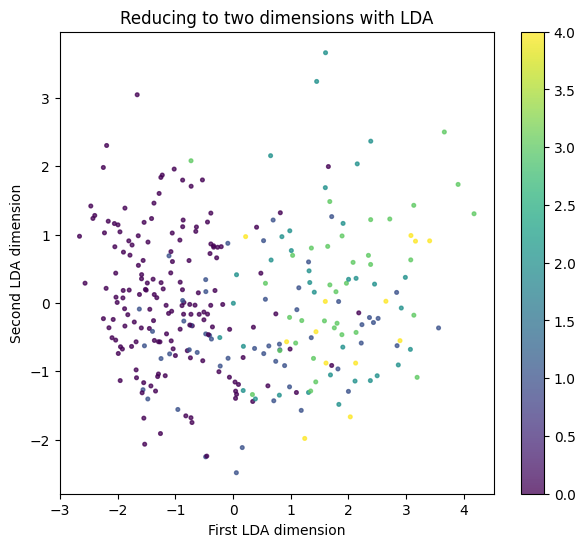

KPCA output shape: (297, 2)


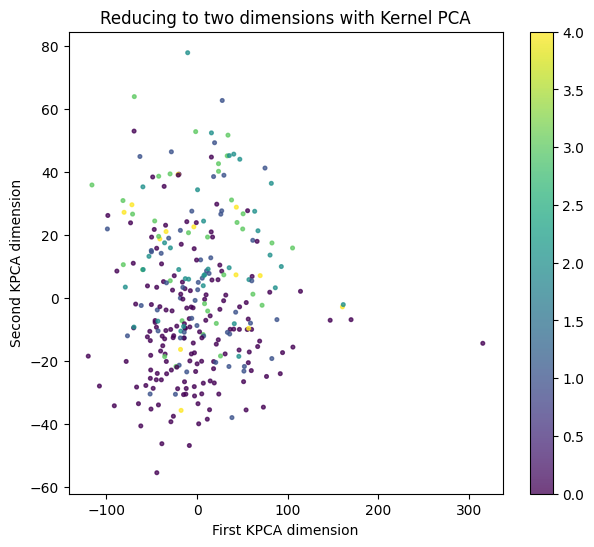

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import KernelPCA

# 1. Reload the raw data fresh so column 13 retains its original multiclass targets (0, 1, 2, 3, 4)
df_lda = pd.read_csv('processed.cleveland.data', header=None)
df_lda = df_lda.apply(pd.to_numeric, errors='coerce').dropna()

X_dr = df_lda.iloc[:, 0:13].values
y_dr = df_lda[13].values

# 2. Linear Discriminant Analysis (LDA)
# With 5 classes, n_components=2 is valid since 2 <= (5 - 1)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_dr, y_dr)

print("LDA output shape:", X_lda.shape)

plt.figure(figsize=(7, 6))
plt.title('Reducing to two dimensions with LDA')
plt.scatter(X_lda[:, 0], X_lda[:, 1], s=7, c=y_dr, alpha=0.75)
plt.xlabel('First LDA dimension')
plt.ylabel('Second LDA dimension')
plt.colorbar()
plt.savefig('ch.3.LDA.png', bbox_inches='tight', dpi=350)
plt.show()

# 3. Kernel Principal Component Analysis (KPCA)
kpca = KernelPCA(n_components=2, kernel='linear')
X_kpca = kpca.fit_transform(X_dr)

print("KPCA output shape:", X_kpca.shape)

plt.figure(figsize=(7, 6))
plt.title('Reducing to two dimensions with Kernel PCA')
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], s=7, c=y_dr, alpha=0.75)
plt.xlabel('First KPCA dimension')
plt.ylabel('Second KPCA dimension')
plt.colorbar()
plt.savefig('ch.3.KPCA.png', bbox_inches='tight', dpi=350)
plt.show()

SPCA output shape: (2000, 2)


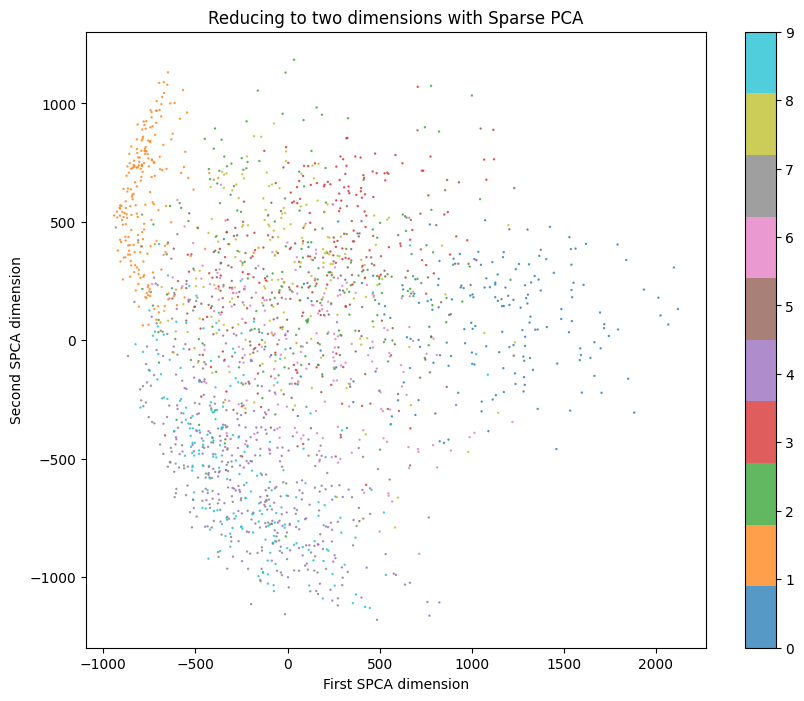

DL output shape: (2000, 2)


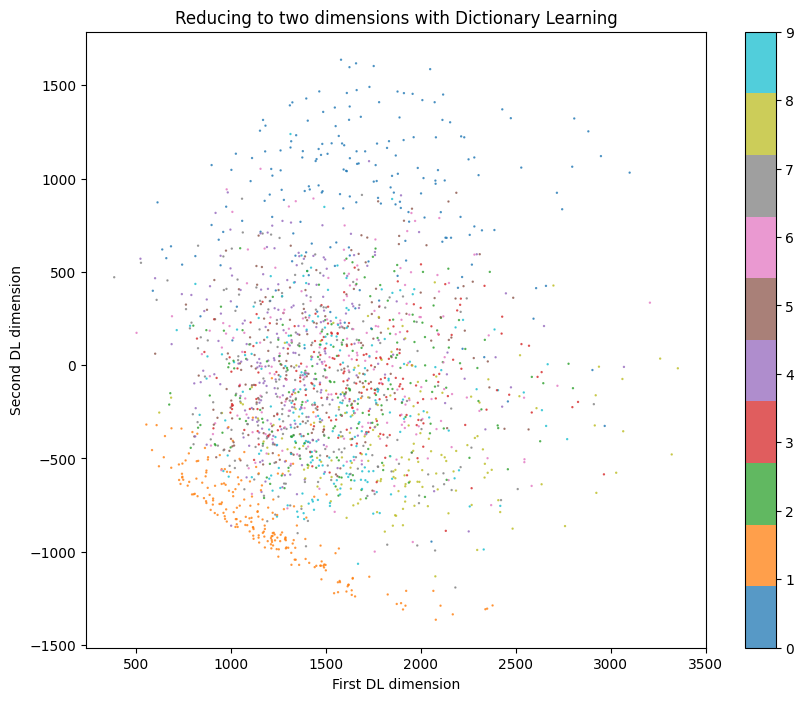

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import MiniBatchDictionaryLearning, MiniBatchSparsePCA

# Using a subset of MNIST to keep computation fast in Colab
X_mnist = mnist.data[:2000]
y_mnist = list(map(int, mnist.target[:2000]))

# 1. Sparse PCA
spca = MiniBatchSparsePCA(n_components=2, batch_size=50, verbose=0)
X_spca = spca.fit_transform(X_mnist)

print("SPCA output shape:", X_spca.shape)

plt.figure(figsize=(10, 8))
plt.title('Reducing to two dimensions with Sparse PCA')
plt.scatter(
    X_spca[:, 0], X_spca[:, 1], s=0.5, c=y_mnist, alpha=0.75, cmap='tab10'
)
plt.xlabel('First SPCA dimension')
plt.ylabel('Second SPCA dimension')
plt.colorbar()
plt.savefig('ch.3.SPCA.png', bbox_inches='tight', dpi=350)
plt.show()

# 2. Dictionary Learning
dl = MiniBatchDictionaryLearning(n_components=2, batch_size=50, verbose=False)
X_dl = dl.fit_transform(X_mnist)

print("DL output shape:", X_dl.shape)

plt.figure(figsize=(10, 8))
plt.title('Reducing to two dimensions with Dictionary Learning')
plt.scatter(
    X_dl[:, 0], X_dl[:, 1], s=0.5, c=y_mnist, alpha=0.75, cmap='tab10'
)
plt.xlabel('First DL dimension')
plt.ylabel('Second DL dimension')
plt.colorbar()
plt.savefig('ch.3.DL.png', bbox_inches='tight', dpi=350)
plt.show()

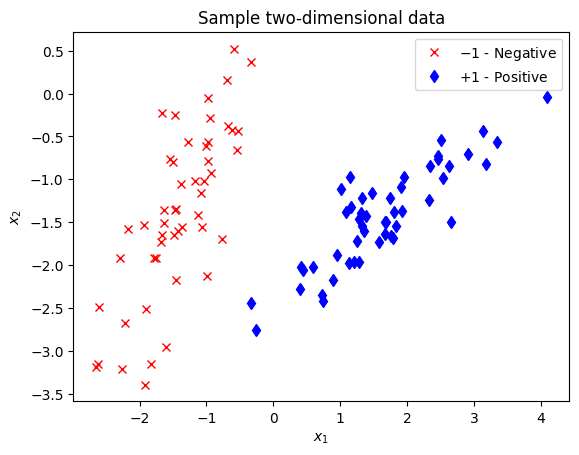

In [20]:
#week 4
# ==========================================
# CELL 1: Training a Single Model / Visualizing Data
# ==========================================
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0,
                           n_clusters_per_class=1, class_sep=1.5,
                           random_state=5)

# Convert 0 labels to -1 for the perceptron math
y[y==0] = -1

fig = plt.figure()

# Plotting initial legend markers (using empty arrays to avoid double plotting points)
plt.plot([], [], 'rx', label='$-1$ - Negative')
plt.plot([], [], 'bd', label='$+1$ - Positive')

# Plotting each point iteratively (as written in the original source)
for i in range(len(y)):
    x1 = X[i,0]
    x2 = X[i,1]
    if (y[i] == -1):
        plt.plot(x1, x2, 'rx')
    else:
        plt.plot(x1, x2, 'bd')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.title('Sample two-dimensional data')
plt.axis('tight')

# Save and display
plt.savefig('ch.5.two-class.data.png', dpi=350, bbox_inches='tight')
plt.savefig('ch.5.two-class.data.eps', dpi=350, bbox_inches='tight')
plt.show()

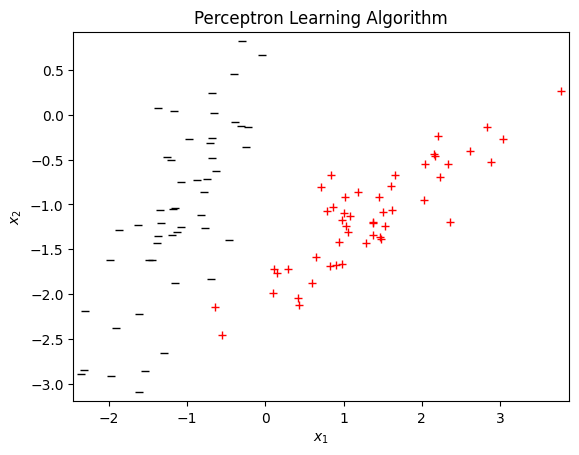

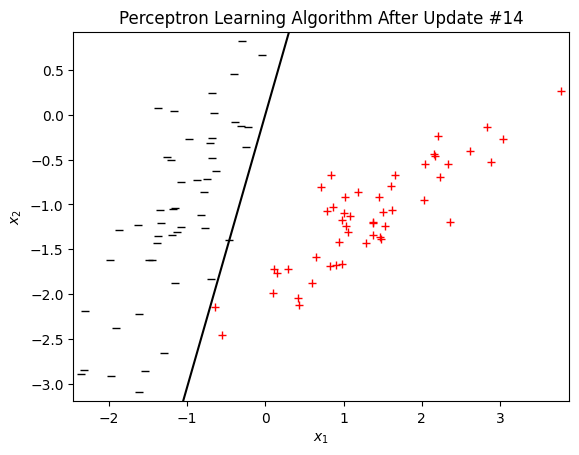

Total iterations:  14


In [21]:
# ==========================================
# Perceptron Learning Algorithm (in Python)
# ==========================================
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

def pltPer(X, y, W, it=-1):
    title = "Perceptron Learning Algorithm"
    if it > 0:
        title = title + " After Update #" + str(it)

    f = plt.figure()
    for n in range(len(y)):
        if y[n] == 1:
            plt.plot(X[n,1], X[n,2], 'r+')
        else:
            plt.plot(X[n,1], X[n,2], 'k_')

    # FIXED: Prevent division by zero on the first iteration when weights are all 0
    if W[2] != 0:
        m, b = -W[1]/W[2], -W[0]/W[2]
        l = np.linspace(min(X[:,1]), max(X[:,1]))
        plt.plot(l, m*l+b, 'k-')

    plt.axis('tight')
    plt.xlim(min(X[:,1])-0.1, max(X[:,1])+0.1)
    plt.ylim(min(X[:,2])-0.1, max(X[:,2])+0.1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.savefig('ch.5.PLA.'+str(it)+'.png', dpi=350, bbox_inches='tight')
    plt.show()

def classification_error(w, X, y):
    err_cnt = 0
    N = len(X)
    for n in range(N):
        s = np.sign(np.dot(w.T, X[n])) # if this is zero, then :(
        if y[n] != s:
            err_cnt += 1
    return err_cnt

def choose_miscl_point(w, X, y):
    mispts = []
    # Choose a random point among the misclassified
    for n in range(len(X)):
        if np.sign(np.dot(w.T, X[n])) != y[n]:
            mispts.append((X[n], y[n]))
    return mispts[random.randrange(0, len(mispts))]

# Main routine
N = 100
random.seed(7)
np.random.seed(7)

X, y = make_classification(n_samples=N, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0,
                           n_clusters_per_class=1, class_sep=1.2,
                           random_state=5)

y[y==0] = -1
X_train = np.append(np.ones((N, 1)), X, axis=1) # add a column of ones

# initialize the weights to zeros
w = np.zeros(X_train.shape[1])
it = 0
pltPer(X_train, y, w) # initial solution (likely bad)

# Iterate until all points are correctly classified
while classification_error(w, X_train, y) != 0:
    it += 1
    # Pick random misclassified point
    x_point, s_label = choose_miscl_point(w, X_train, y)
    # Update weights
    w += s_label * x_point
    if it > 1000:
        break

pltPer(X_train, y, w, it)
print("Total iterations: ", it)

Running simulations, please wait...

Mean iterations per separation level:
[  2.787   3.049   3.337   3.671   4.125   4.901   6.674  10.318  24.217
 184.414]

Standard deviation per separation level:
[ 1.21063248  1.33214076  1.56761953  1.8549283   2.36672242  2.99919973
  4.74317657  7.78966469 15.91967057 75.52670127]


/tmp/ipykernel_925/2612084508.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(PLAData, labels=['2.0', '1.9', '1.8', '1.7', '1.6', '1.5', '1.4', '1.3', '1.2', '1.1'],


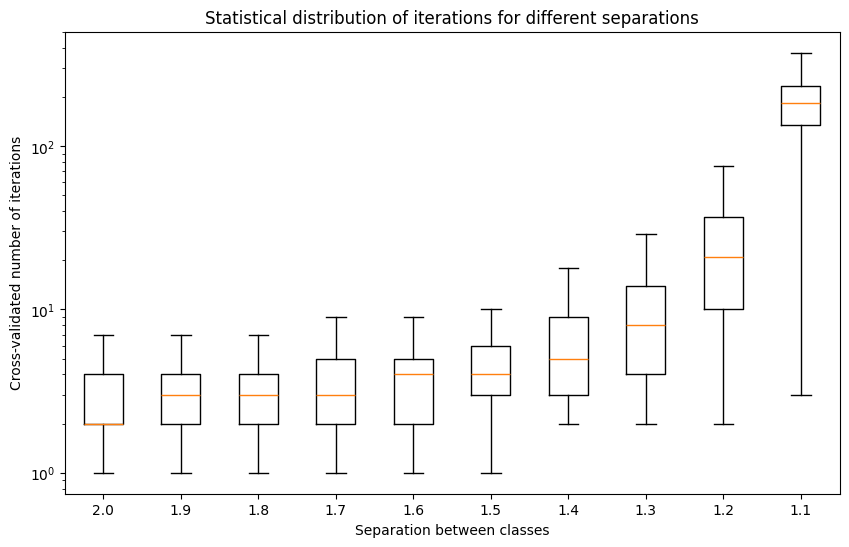

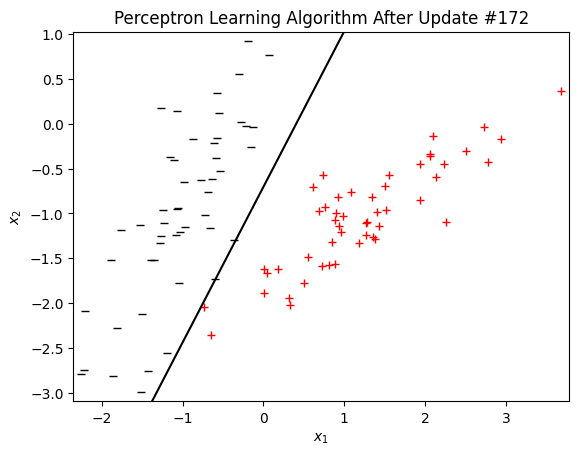

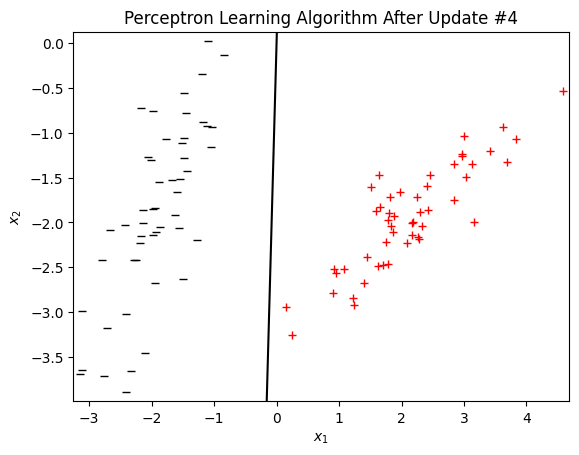

In [22]:
# ==========================================
# CELL 3: Convergence on Linearly Separable Data
# ==========================================
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Using the definitions from Cell 2, wrapped cleanly
def perceptron_la(X, y):
    N = len(X)
    X_train = np.append(np.ones((N,1)), X, axis=1)
    w = np.zeros(X_train.shape[1])
    it = 0

    while classification_error(w, X_train, y) != 0:
        it += 1
        x_point, s_label = choose_miscl_point(w, X_train, y)
        w += s_label * x_point
        if it > 1000:
            break
    return X_train, w, it

N = 100
random.seed(7)
np.random.seed(7)

# FIXED: Standardized numpy shape syntax
PLAData = np.zeros((1000, 10), dtype=int)

cnt = 0
print("Running simulations, please wait...")
for separation in np.arange(2.0, 1.0, -0.1):
    for k in range(1000):
        X, y = make_classification(n_samples=N, n_features=2, n_classes=2,
                                   n_informative=2, n_redundant=0, n_repeated=0,
                                   n_clusters_per_class=1, class_sep=separation,
                                   random_state=5)
        y[y==0] = -1
        _, _, it = perceptron_la(X, y)
        PLAData[k, cnt] = it
    cnt += 1

print("\nMean iterations per separation level:")
print(np.mean(PLAData, axis=0))
print("\nStandard deviation per separation level:")
print(np.std(PLAData, axis=0))

plt.figure(figsize=(10,6))
plt.boxplot(PLAData, labels=['2.0', '1.9', '1.8', '1.7', '1.6', '1.5', '1.4', '1.3', '1.2', '1.1'],
            showfliers=False)
plt.yscale('log')
plt.xlabel('Separation between classes')
plt.ylabel('Cross-validated number of iterations')
plt.title('Statistical distribution of iterations for different separations')
plt.axis('tight')
plt.savefig('ch.5.two-class.boxplot.cv.png', dpi=350, bbox_inches='tight')
plt.show()

# Visualize specific difficult vs easy separations
X, y = make_classification(n_samples=N, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0,
                           n_clusters_per_class=1, class_sep=1.1,
                           random_state=5)
y[y==0] = -1
X_train, w, it = perceptron_la(X, y)
pltPer(X_train, y, w, it)

X, y = make_classification(n_samples=N, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0,
                           n_clusters_per_class=1, class_sep=2.0,
                           random_state=5)
y[y==0] = -1
X_train, w, it = perceptron_la(X, y)
pltPer(X_train, y, w, it)

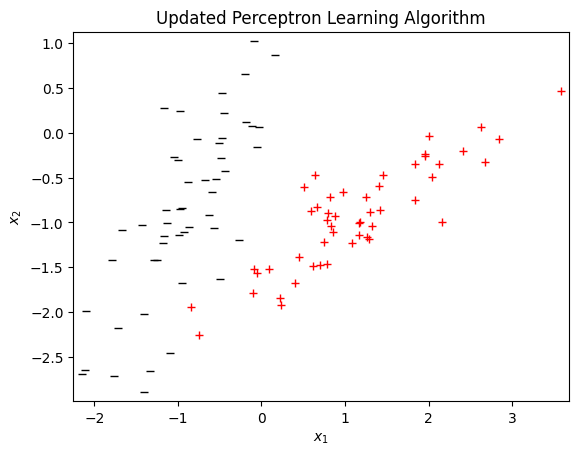

0 100 [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
1 44 [np.float64(1.0), np.float64(1.2835669814481265), np.float64(-1.1823332177237444)]
2 7 [np.float64(0.0), np.float64(2.0558690185493607), np.float64(-1.1170552325689436)]
8 3 [np.float64(0.0), np.float64(3.8733643096363752), np.float64(-0.9610763449366988)]
27 2 [np.float64(-1.0), np.float64(6.922083593872955), np.float64(-1.9221623632273177)]
95 1 [np.float64(-3.0), np.float64(8.641360946984442), np.float64(-4.2459333002463655)]


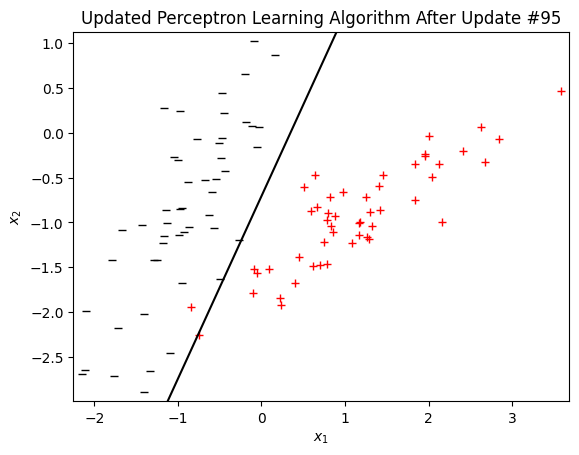

95 1 [np.float64(-3.0), np.float64(8.641360946984442), np.float64(-4.2459333002463655)]
Best found at iteration:  95
Number of misclassified points:  1


In [24]:
# ==========================================
# CELL 4: Convergence on Non-Linearly Separable Data (Full Verbatim)
# ==========================================
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

def pltPer(X, y, W, it=-1):
    title = "Updated Perceptron Learning Algorithm"
    if it > 0:
        title = title + " After Update #" + str(it)

    f = plt.figure()
    for n in range(len(y)):
        if y[n] == 1:
            plt.plot(X[n,1], X[n,2], 'r+')
        else:
            plt.plot(X[n,1], X[n,2], 'k_')

    if W[2] != 0:
        m, b = -W[1]/W[2], -W[0]/W[2]
        l = np.linspace(min(X[:,1]), max(X[:,1]))
        plt.plot(l, m*l+b, 'k-')

    plt.axis('tight')
    plt.xlim(min(X[:,1])-0.1, max(X[:,1])+0.1)
    plt.ylim(min(X[:,2])-0.1, max(X[:,2])+0.1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.savefig('ch.5.UPLA.'+str(it)+'.png', dpi=350, bbox_inches='tight')
    plt.savefig('ch.5.UPLA.'+str(it)+'.eps', dpi=350, bbox_inches='tight')
    plt.show()

def classification_error(w, X, y):
    s = np.sign(X.dot(w))
    return sum(s != y)

def choose_miscl_point(w, X, y):
    for idx in np.random.permutation(len(X)):
        if np.sign(w.T.dot(X[idx])) != y[idx]:
            return X[idx], y[idx]

# main
N = 100
random.seed(a = 7)
np.random.seed(7)

X, y = make_classification(n_samples=N, n_features=2, n_classes=2,
                           n_informative=2, n_redundant=0, n_repeated=0,
                           n_clusters_per_class=1, class_sep=1.0,
                           random_state=5)

y[y==0] = -1

X_train = np.append(np.ones((N,1)), X, 1)  # add a column of ones

# initialize the weights to zeros
w = np.zeros(X_train.shape[1])
it = 0
bestW = {}
bestW['err'] = N + 1  # dictionary to keep best solution
bestW['w'] = []
bestW['it'] = it
pltPer(X_train, y, w)  # initial solution (likely bad)

# Iterate until all points are correctly classified
while it < 1000:
    err = classification_error(w, X_train, y)
    if err < bestW['err']:  # enter to save a new w
        bestW['err'] = err
        bestW['it'] = it
        bestW['w'] = list(w)
        print(it, bestW['err'], bestW['w'])
    if err == 0:
        break
    it += 1
    # Pick random misclassified point
    x, s = choose_miscl_point(w, X_train, y)
    # Update weights
    w += s*x

pltPer(X_train, y, np.array(bestW['w']), bestW['it'])
print(bestW['it'], bestW['err'], bestW['w'])
print("Best found at iteration: ", bestW['it'])
print("Number of misclassified points: ", bestW['err'])

In [28]:
#week 5
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load dataset directly from Colab's working directory
df = pd.read_csv("heart.csv")

# Features and target
X = df.drop('target', axis=1).values
y = df['target'].values.reshape(-1, 1)

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# MLP Parameters
m = X_train.shape[0]       # Number of training samples
input_size = X_train.shape[1]
hidden_size = 5
output_size = 1
learning_rate = 0.1
epochs = 1000              # Increased from 10 to allow convergence

# Sigmoid Activation and Derivative
def sigmoid(x):
    # np.clip prevents overflow in exp()
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Weight and bias initialization
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Training Loop
for epoch in range(epochs):
    # Forward Pass
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Loss Tracking (Mean Squared Error)
    loss = np.mean((y_train - A2) ** 2)

    # Backward Pass (Averaged across batch size 'm')
    dA2 = A2 - y_train
    dZ2 = dA2 * sigmoid_derivative(A2)
    dW2 = (1 / m) * np.dot(A1.T, dZ2)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (1 / m) * np.dot(X_train.T, dZ1)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    # Update weights and biases
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Print details periodically
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Loss: {loss:.4f}")

# Prediction on test set
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

preds = (A2_test > 0.5).astype(int)
accuracy = np.mean(preds == y_test)

print("\n--- Final Model Weights ---")
print("W1:\n", W1.round(4))
print("b1:\n", b1.round(4))
print("W2:\n", W2.round(4))
print("b2:\n", b2.round(4))
print(f"\n✅ Final Test Accuracy: {accuracy * 100:.2f}%")

Epoch 1/1000 | Loss: 0.2926
Epoch 100/1000 | Loss: 0.2809
Epoch 200/1000 | Loss: 0.2729
Epoch 300/1000 | Loss: 0.2668
Epoch 400/1000 | Loss: 0.2618
Epoch 500/1000 | Loss: 0.2578
Epoch 600/1000 | Loss: 0.2544
Epoch 700/1000 | Loss: 0.2514
Epoch 800/1000 | Loss: 0.2488
Epoch 900/1000 | Loss: 0.2464
Epoch 1000/1000 | Loss: 0.2440

--- Final Model Weights ---
W1:
 [[ 0.3182 -0.116   0.5129  1.4898 -0.1785]
 [-0.6487  1.6417  0.5174 -0.5368  0.6772]
 [-0.0944 -0.5524  0.3923 -1.8917 -1.8943]
 [-0.6254 -1.0133  0.2512 -0.9226 -1.4078]
 [ 1.4144 -0.2254  0.0139 -1.4387 -0.5373]
 [ 0.0782 -1.1577  0.3749 -0.6087 -0.2962]
 [-0.54    1.8207 -0.0135 -1.0542  0.7832]
 [-1.0755  0.1528 -1.9213 -1.3336  0.0989]
 [ 0.0949  0.2917 -0.4791 -0.3708 -1.2216]
 [-0.9346 -0.4217  0.9148  0.3191 -1.6778]
 [ 0.5597 -0.4587 -0.6015  0.61    0.8972]
 [ 0.6245 -0.7839 -0.4794  0.2873  1.0995]
 [-0.7247 -0.1642 -1.2899 -1.2428  0.8814]]
b1:
 [[-0.0943 -0.0214 -0.1319 -0.04   -0.0116]]
W2:
 [[ 1.0463]
 [-0.3781]
 

Initiating official dataset download. This will take ~20-30 minutes on the throttled server...
x_train shape: (50000, 3072)
x_test shape: (10000, 3072)


Model: "widenet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inpt_vec (InputLayer)           │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dropout)                    │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l1 (Dense)                      │ (None, 3072)           │     9,440,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dropout)                    │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2 (Dense)                      │ (None, 3072)           │     9,440,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │        30,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,911,242 (72.14 MB)

 Trainable params: 18,911,242 (72.14 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 0.4070 - val_loss: 0.3003 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2970 - val_loss: 0.2846 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2832 - val_loss: 0.2709 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2766 - val_loss: 0.2654 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2724 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2682 - val_loss: 0.2624 - learning_rate: 0.0010
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2659 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2628 - val_loss: 0.2510 - learning_rate: 0.0010
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2599 - val_loss: 0.2533 - learning_rate: 0.00

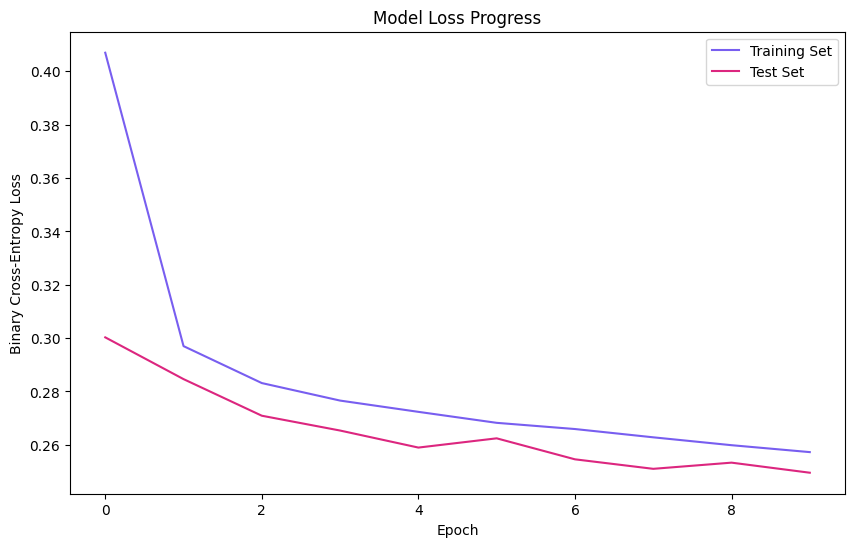

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.40      0.60      0.48      1000
           1       0.58      0.31      0.40      1000
           2       0.31      0.23      0.26      1000
           3       0.38      0.20      0.26      1000
           4       0.37      0.37      0.37      1000
           5       0.38      0.37      0.38      1000
           6       0.44      0.52      0.48      1000
           7       0.51      0.41      0.45      1000
           8       0.44      0.65      0.53      1000
           9       0.42      0.54      0.47      1000

    accuracy                           0.42     10000
   macro avg       0.42      0.42      0.41     10000
weighted avg       0.42      0.42      0.41     10000

BER: 0.5809


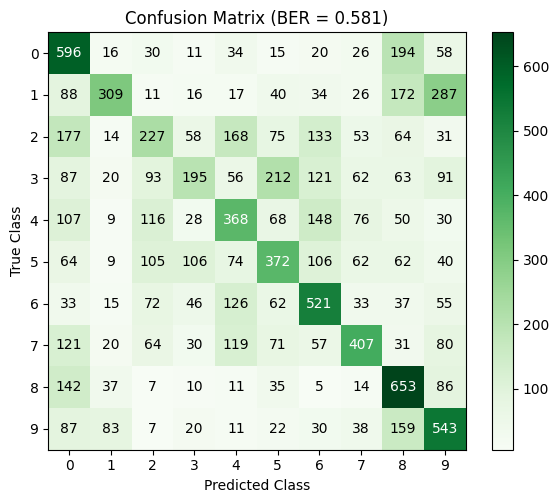

In [3]:
#week 6
# ==========================================
# CELL 1: CIFAR-10 Data Prep & Wide Neural Network
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("Initiating official dataset download. This will take ~20-30 minutes on the throttled server...")

# 1. Official Data Load (Let it run until 100%)
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

# Normalize and Flatten for Dense Networks
x_train = x_train_raw.astype('float32') / 255.
x_test = x_test_raw.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# One-hot encode targets
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

# 2. Build Wide Neural Network
inpt_dim = 32 * 32 * 3
inpt_vec = Input(shape=(inpt_dim,), name='inpt_vec')
dl = Dropout(0.5, name='d1')(inpt_vec)
l1 = Dense(inpt_dim, activation='relu', name='l1')(dl)
d2 = Dropout(0.2, name='d2')(l1)
l2 = Dense(inpt_dim, activation='relu', name='l2')(d2)
output = Dense(10, activation='sigmoid', name='output')(l2)

widenet = Model(inpt_vec, output, name='widenet')
widenet.compile(loss='binary_crossentropy', optimizer='adam')
widenet.summary()

# 3. Train the Model with Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20)
stop_alg = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

# Sliced to 15,000 samples for 10 epochs so the actual training finishes quickly once the download is done
print("Starting training...")
hist = widenet.fit(x_train[:15000], y_train[:15000], batch_size=256, epochs=10,
                   callbacks=[stop_alg, reduce_lr], shuffle=True,
                   validation_data=(x_test[:3000], y_test[:3000]))

widenet.save_weights("widenet.weights.h5")

# 4. Plot Loss
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0', label='Training Set')
plt.plot(hist.history['val_loss'], color='#dc267f', label='Test Set')
plt.title('Model Loss Progress')
plt.ylabel('Binary Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig('ch.11.wn.cifar10.loss.png', dpi=350, bbox_inches='tight')
plt.show()

# 5. Evaluate Model
y_hat = widenet.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print(classification_report(y_true, y_pred, labels=labels))
cm = confusion_matrix(y_true, y_pred, labels=labels)
ber = 1 - balanced_accuracy_score(y_true, y_pred)
print('BER:', ber)

# 6. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=labels, yticklabels=labels,
       title='Confusion Matrix (BER = {0:0.3f})'.format(ber),
       ylabel='True Class', xlabel='Predicted Class')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.savefig('ch.11.wn.cifar10.cm.png', dpi=350, bbox_inches='tight')
plt.show()

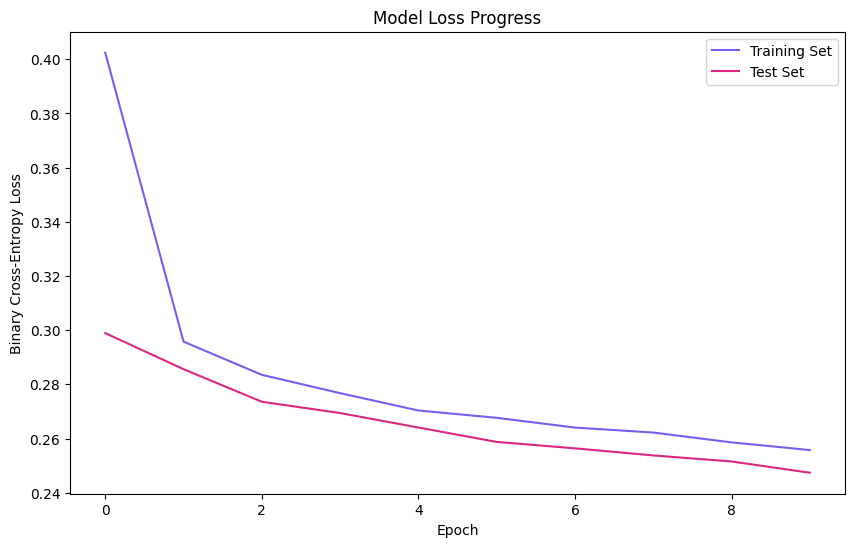

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
              precision    recall  f1-score   support

           0       0.53      0.46      0.49      1000
           1       0.55      0.50      0.53      1000
           2       0.39      0.12      0.18      1000
           3       0.36      0.17      0.23      1000
           4       0.34      0.41      0.37      1000
           5       0.36      0.35      0.36      1000
           6       0.37      0.63      0.47      1000
           7       0.40      0.51      0.45      1000
           8       0.49      0.62      0.55      1000
           9       0.45      0.49      0.47      1000

    accuracy                           0.42     10000
   macro avg       0.43      0.42      0.41     10000
weighted avg       0.43      0.42      0.41     10000

BER: 0.5751


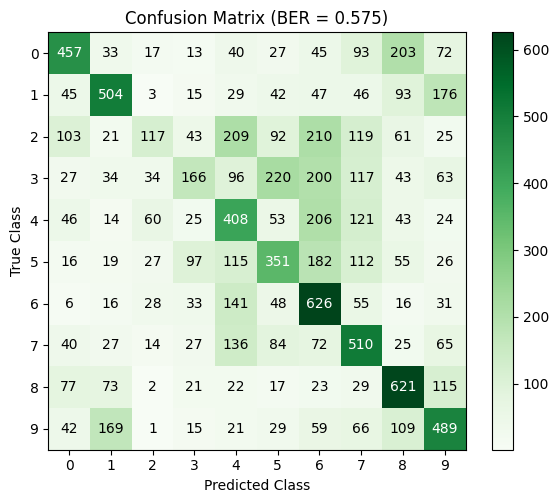

In [11]:
# Save weights with the correct Keras 3 extension
widenet.save_weights("widenet.weights.h5")

# 4. Plot Loss
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0', label='Training Set')
plt.plot(hist.history['val_loss'], color='#dc267f', label='Test Set')
plt.title('Model Loss Progress')
plt.ylabel('Binary Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig('ch.11.wn.cifar10.loss.png', dpi=350, bbox_inches='tight')
plt.show()

# 5. Evaluate Model
y_hat = widenet.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print(classification_report(y_true, y_pred, labels=labels))
cm = confusion_matrix(y_true, y_pred, labels=labels)
ber = 1 - balanced_accuracy_score(y_true, y_pred)
print('BER:', ber)

# 6. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=labels, yticklabels=labels,
       title='Confusion Matrix (BER = {0:0.3f})'.format(ber),
       ylabel='True Class', xlabel='Predicted Class')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.savefig('ch.11.wn.cifar10.cm.png', dpi=350, bbox_inches='tight')
plt.show()

In [12]:
# ==========================================
# CELL 2: Dense Deep Neural Network
# ==========================================
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

inpt_dim = 32 * 32 * 3
inpt_vec = Input(shape=(inpt_dim,))

units = inpt_dim
dr = 0.5
dl = Dropout(dr)(inpt_vec)
dl = Dense(units, activation='relu')(dl)

units = units // 2
dr = dr / 2
while units > 10:
    dl = Dropout(dr)(dl)
    dl = Dense(units, activation='relu')(dl)
    units = units // 2
    dr = dr / 1.5

output = Dense(10, activation='sigmoid')(dl)
deepnet = Model(inpt_vec, output)

deepnet.compile(loss='binary_crossentropy', optimizer='adam')
deepnet.summary()

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_delta=1e-4, mode='min')
stop_alg = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

hist = deepnet.fit(x_train, y_train, batch_size=1000, epochs=100, # Kept to 100 for faster execution
                   callbacks=[stop_alg, reduce_lr], shuffle=True,
                   validation_data=(x_test, y_test))

deepnet.save_weights("deepnet.hdf5")

# Plot Loss
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0', label='Training Set')
plt.plot(hist.history['val_loss'], color='#dc267f', label='Test Set')
plt.title('Deep Network Loss Progress')
plt.ylabel('Binary Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig('ch.11.dn.cifar10.loss.png', dpi=350, bbox_inches='tight')
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3072)           │     9,440,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1536)           │     4,720,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 768)            │     1,180,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 384)            │       295,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,734,806 (60.02 MB)

 Trainable params: 15,734,806 (60.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - loss: 0.5953 - val_loss: 0.5244 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.4678 - val_loss: 0.3982 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.3618 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.3230 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.3090 - val_loss: 0.2965 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.2997 - val_loss: 0.2892 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.2938 - val_loss: 0.2825 - learning_rate: 0.0010
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2899 - val_loss: 0.2792 - learning_rate: 0.0010
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2864 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 10/

ValueError: The filename must end in `.weights.h5`. Received: filepath=deepnet.hdf5

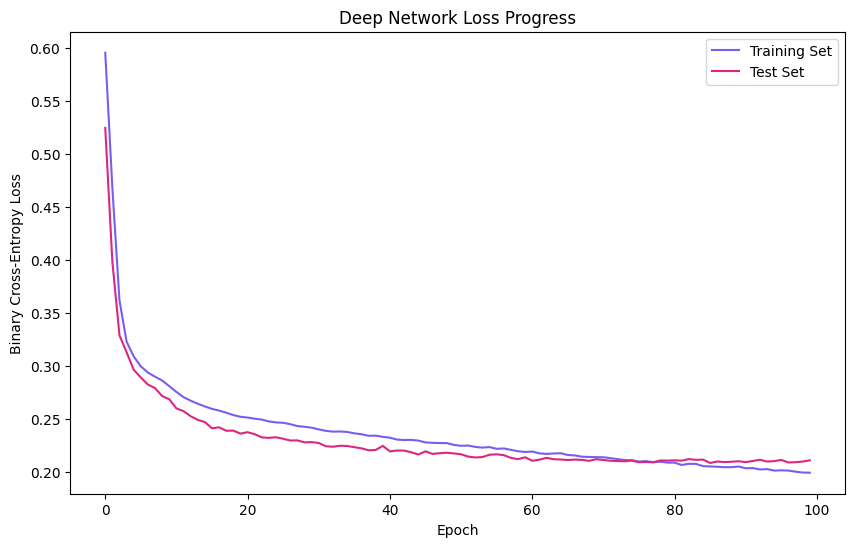

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
              precision    recall  f1-score   support

           0       0.61      0.61      0.61      1000
           1       0.70      0.63      0.66      1000
           2       0.44      0.35      0.39      1000
           3       0.37      0.38      0.37      1000
           4       0.40      0.51      0.45      1000
           5       0.56      0.27      0.36      1000
           6       0.44      0.71      0.55      1000
           7       0.62      0.56      0.59      1000
           8       0.64      0.68      0.66      1000
           9       0.61      0.60      0.60      1000

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.52     10000
weighted avg       0.54      0.53      0.52     10000

BER: 0.4719


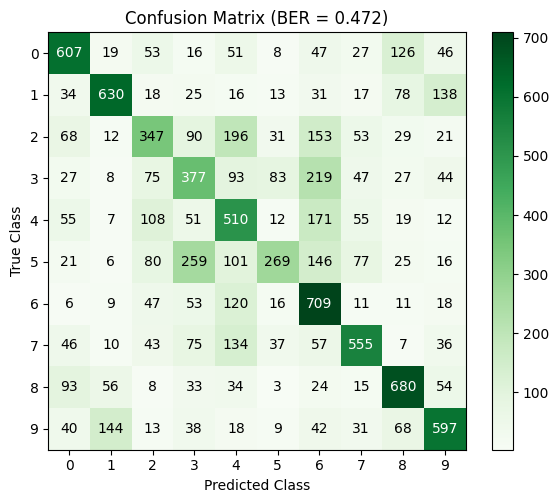

In [13]:
# Save weights with the correct Keras 3 extension
deepnet.save_weights("deepnet.weights.h5")

# 4. Plot Loss
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0', label='Training Set')
plt.plot(hist.history['val_loss'], color='#dc267f', label='Test Set')
plt.title('Deep Network Loss Progress')
plt.ylabel('Binary Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.savefig('ch.11.dn.cifar10.loss.png', dpi=350, bbox_inches='tight')
plt.show()

# 5. Evaluate Model
y_hat = deepnet.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print(classification_report(y_true, y_pred, labels=labels))
cm = confusion_matrix(y_true, y_pred, labels=labels)
ber = 1 - balanced_accuracy_score(y_true, y_pred)
print('BER:', ber)

# 6. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=labels, yticklabels=labels,
       title='Confusion Matrix (BER = {0:0.3f})'.format(ber),
       ylabel='True Class', xlabel='Predicted Class')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
plt.savefig('ch.11.dn.cifar10.cm.png', dpi=350, bbox_inches='tight')
plt.show()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3072)           │     9,440,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1536)           │     4,720,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 768)            │     1,180,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 384)            │       295,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,734,806 (60.02 MB)

 Trainable params: 15,734,806 (60.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 1.3125 - val_loss: 1.2406 - learning_rate: 1.0000e-05
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.2231 - val_loss: 1.1617 - learning_rate: 1.0000e-05
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.1471 - val_loss: 1.0914 - learning_rate: 1.0000e-05
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0805 - val_loss: 1.0332 - learning_rate: 1.0000e-05
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0221 - val_loss: 0.9796 - learning_rate: 1.0000e-05
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9708 - val_loss: 0.9315 - learning_rate: 1.0000e-05
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.9238 - val_loss: 0.8909 - learning_rate: 1.0000e-05
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8818 - val_loss: 0.8502 - learning_rate: 1.0000e-05
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8440 - va

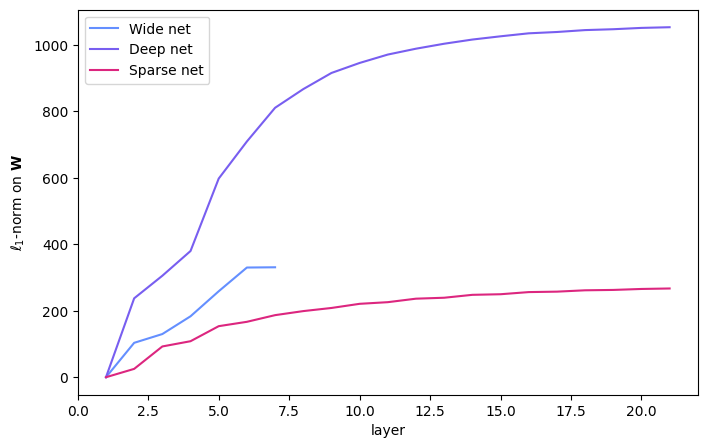

In [15]:
# ==========================================
# CELL 3: Sparse Deep Neural Network & Weight Comparison
# ==========================================
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

units = inpt_dim
dr = 0.25
dl = Dropout(dr)(inpt_vec)
dl = Dense(units, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(dl)

units = units // 2
dr = dr / 1.125
while units > 10:
    dl = Dropout(dr)(dl)
    dl = Dense(units, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(dl)
    units = units // 2
    dr = dr / 1.125

output = Dense(10, activation='sigmoid', kernel_regularizer=regularizers.l2(0.0001))(dl)
sparsenet = Model(inpt_vec, output)

# FIXED: 'lr' is deprecated in Adam. Replaced with 'learning_rate'
optmzr = Adam(learning_rate=0.00001)
sparsenet.compile(loss='binary_crossentropy', optimizer=optmzr)
sparsenet.summary()

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=20)
stop_alg = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

hist = sparsenet.fit(x_train, y_train, batch_size=128, epochs=100,
                     callbacks=[stop_alg, reduce_lr], shuffle=True,
                     validation_data=(x_test, y_test))

sparsenet.save_weights("sparsenet.weights.h5")

# --- Weight Regularization Comparison ---
ww = widenet.get_weights()
dw = deepnet.get_weights()
sw = sparsenet.get_weights()

fig = plt.figure(figsize=(8,5))
wh, dh, sh = [0.0], [0.0], [0.0]

for i in range(np.max([len(ww), len(dw), len(sw)])):
    if i < len(ww):
        wh.append(wh[-1] + np.linalg.norm(ww[i], ord=1))
    else:
        wh.append(np.nan)

    if i < len(dw):
        dh.append(dh[-1] + np.linalg.norm(dw[i], ord=1))
    else:
        dh.append(np.nan)

    if i < len(sw):
        sh.append(sh[-1] + np.linalg.norm(sw[i], ord=1))
    else:
        sh.append(np.nan)

plt.plot([i+1 for i in range(len(wh))], wh, color='#648fff', label='Wide net')
plt.plot([i+1 for i in range(len(dh))], dh, color='#785ef0', label='Deep net')
plt.plot([i+1 for i in range(len(sh))], sh, color='#dc267f', label='Sparse net')
plt.xlabel('layer')
plt.ylabel(r'$\ell_1$-norm on $\mathbf{W}$')
plt.legend()
plt.show()

In [4]:
# ==========================================
# CELL 4: Hyper-Parameter Optimization
# ==========================================
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

def create_model(dr=0.0, optimizer='adam', lr=0.001, units=128):
    inpt_dim = 32 * 32 * 3
    inpt_vec = Input(shape=(inpt_dim,))
    dl = Dropout(dr)(inpt_vec)
    l1 = Dense(units, activation='relu')(dl)
    dl2 = Dropout(dr)(l1)
    l2 = Dense(units, activation='relu')(dl2)
    output = Dense(10, activation='sigmoid')(l2)

    model = Model(inpt_vec, output)

    if optimizer == 'adam':
        optmzr = Adam(learning_rate=lr)
    else:
        optmzr = RMSprop(learning_rate=lr)

    model.compile(loss='binary_crossentropy', optimizer=optmzr, metrics=['accuracy'])
    return model

model = KerasClassifier(
    model=create_model, epochs=10, batch_size=1000, verbose=0,
    model__dr=0.0, model__optimizer='adam', model__lr=0.001, model__units=128
)

param_grid = {
    'model__dr': [0.2],
    'model__optimizer': ['adam'],
    'model__lr': [0.01],
    'model__units': [512]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=1, cv=2, verbose=2)

grid_result = grid.fit(
    x_train[:5000], y_train[:5000], validation_split=0.3,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

Fitting 2 folds for each of 1 candidates, totalling 2 fits
[CV] END model__dr=0.2, model__lr=0.01, model__optimizer=adam, model__units=512; total time=  15.9s


[CV] END model__dr=0.2, model__lr=0.01, model__optimizer=adam, model__units=512; total time=   9.6s
Best: 0.127 using {'model__dr': 0.2, 'model__lr': 0.01, 'model__optimizer': 'adam', 'model__units': 512}


In [5]:
# week 7
# ==========================================
# CELL 5: Convolution in N-Dimensions & Pooling Strategies
# ==========================================
import numpy as np
from scipy.signal import convolve2d, convolve
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D

print("--- 1D Convolutions ---")
print("Full:", np.convolve([2, 3, 2], [-1, 2, -1]))
print("Valid:", np.convolve([2, 3, 2], [-1, 2, -1], 'valid'))
print("Same:", np.convolve([2, 3, 2], [-1, 2, -1], 'same'))

print("\n--- 2D Convolutions ---")
x = np.array([[2,2,2], [2,3,2], [2,2,2]])
w = np.array([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]])
print("Full 2D:\n", convolve2d(x, w))
print("Valid 2D:\n", convolve2d(x, w, mode='valid'))
print("Same 2D:\n", convolve2d(x, w, mode='same'))

print("\n--- N-Dimensional Convolutions ---")
x_nd = np.array([[[1,1],[1,1]], [[2,2],[2,2]]])
w_nd = np.array([[[1,-1],[1,-1]], [[1,-1],[1,-1]]])
print(convolve(x_nd, w_nd))

print("\n--- TensorFlow Conv2D ---")
input_shape = (1, 32, 32, 3)
x_tf = tf.random.normal(input_shape)
y_tf = Conv2D(64, (9,9), strides=(2,2), activation='relu', input_shape=input_shape)(x_tf)
print("Conv2D Output Shape:", y_tf.shape)

print("\n--- Pooling Strategies ---")
x_pool = tf.constant([[-2., -4., -6., -4.],
                      [-4.,  9.,  5.,  9.],
                      [-6.,  5.,  8.,  5.],
                      [-4.,  9.,  5.,  9.]])
x_pool = tf.reshape(x_pool, [1, 4, 4, 1])

y_max = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(x_pool)
print("MaxPooling2D:\n", tf.reshape(y_max, [2, 2]).numpy())

y_avg = AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(x_pool)
print("AveragePooling2D:\n", tf.reshape(y_avg, [2, 2]).numpy())

--- 1D Convolutions ---
Full: [-2  1  2  1 -2]
Valid: [2]
Same: [1 2 1]

--- 2D Convolutions ---
Full 2D:
 [[-2 -4 -6 -4 -2]
 [-4  9  5  9 -4]
 [-6  5  8  5 -6]
 [-4  9  5  9 -4]
 [-2 -4 -6 -4 -2]]
Valid 2D:
 [[8]]
Same 2D:
 [[9 5 9]
 [5 8 5]
 [9 5 9]]

--- N-Dimensional Convolutions ---
[[[ 1  0 -1]
  [ 2  0 -2]
  [ 1  0 -1]]

 [[ 3  0 -3]
  [ 6  0 -6]
  [ 3  0 -3]]

 [[ 2  0 -2]
  [ 4  0 -4]
  [ 2  0 -2]]]

--- TensorFlow Conv2D ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Conv2D Output Shape: (1, 12, 12, 64)

--- Pooling Strategies ---
MaxPooling2D:
 [[9. 9.]
 [9. 9.]]
AveragePooling2D:
 [[-0.25  1.  ]
 [ 1.    6.75]]


In [6]:
# ==========================================
# CELL 6: CNN Training and Filter Visualization
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# 1. Reload Data (without flattening)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Compile the CNN Model
inpt_dim = (32, 32, 3)
inpt_img = Input(shape=inpt_dim)

# Step 1 - Convolution
cl1 = Conv2D(64, (9, 9), strides=(2, 2), activation='relu')(inpt_img)
# Step 2 - Pooling and BN
pl2 = MaxPooling2D(pool_size=(2, 2))(cl1)
bnl3 = BatchNormalization()(pl2)
# Second Convolutional Layer
cl4 = Conv2D(128, (3, 3), strides=(1, 1), activation='relu')(bnl3)
pl5 = MaxPooling2D(pool_size=(2, 2))(cl4)
bnl6 = BatchNormalization()(pl5)

# Step 3 - Flattening
fl7 = Flatten()(bnl6)

# Step 4 - Full connection
dol8 = Dropout(0.5)(fl7)
dl9 = Dense(256, activation='relu')(dol8)
dol10 = Dropout(0.2)(dl9)
dl11 = Dense(64, activation='relu')(dol10)
dol12 = Dropout(0.1)(dl11)
output = Dense(10, activation='sigmoid')(dol12)

classifier = Model(inpt_img, output)
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
classifier.summary()

# 3. Train the CNN
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_delta=1e-4, mode='min', verbose=1)
stop_alg = EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True, verbose=1)

hist = classifier.fit(x_train, y_train, batch_size=100, epochs=50, # Set to 50 for realistic Colab runtime
                      callbacks=[stop_alg, reduce_lr], shuffle=True,
                      validation_data=(x_test, y_test))

classifier.save_weights("cnn.hdf5")

# 4. Visualize Convolutional Filters
cnn1_name = classifier.layers[1].name
W = classifier.get_layer(name=cnn1_name).get_weights()[0]
wshape = W.shape

scaler = MinMaxScaler()
scaler.fit(W.reshape(-1,1))
W = scaler.transform(W.reshape(-1,1))
W = W.reshape(wshape)

fig, axs = plt.subplots(8, 8, figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()

for i in range(W.shape[-1]):
    # reshape to a 3D (RGB) image shape and display
    h = np.reshape(W[:,:,:,i], (9,9,3))
    axs[i].imshow(h)
    axs[i].set_title('Filter ' + str(i))

plt.savefig("ch.12.cnn.full.filters.png", bbox_inches='tight', dpi=350)
plt.show()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,666 (932.29 KB)

 Trainable params: 238,282 (930.79 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3569 - loss: 0.2723 - val_accuracy: 0.3010 - val_loss: 0.3019 - learning_rate: 0.0010
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4770 - loss: 0.2280 - val_accuracy: 0.3031 - val_loss: 0.3216 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5226 - loss: 0.2109 - val_accuracy: 0.5642 - val_loss: 0.1969 - learning_rate: 0.0010
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5566 - loss: 0.1986 - val_accuracy: 0.3639 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5789 - loss: 0.1897 - val_accuracy: 0.4924 - val_loss: 0.2183 - learning_rate: 0.0010
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5952 - loss: 0.1837 - val_accuracy: 0.5923 - val_loss: 0.1859 - learning_rate: 0.0010
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6100 - loss: 0.1779 -

ValueError: The filename must end in `.weights.h5`. Received: filepath=cnn.hdf5

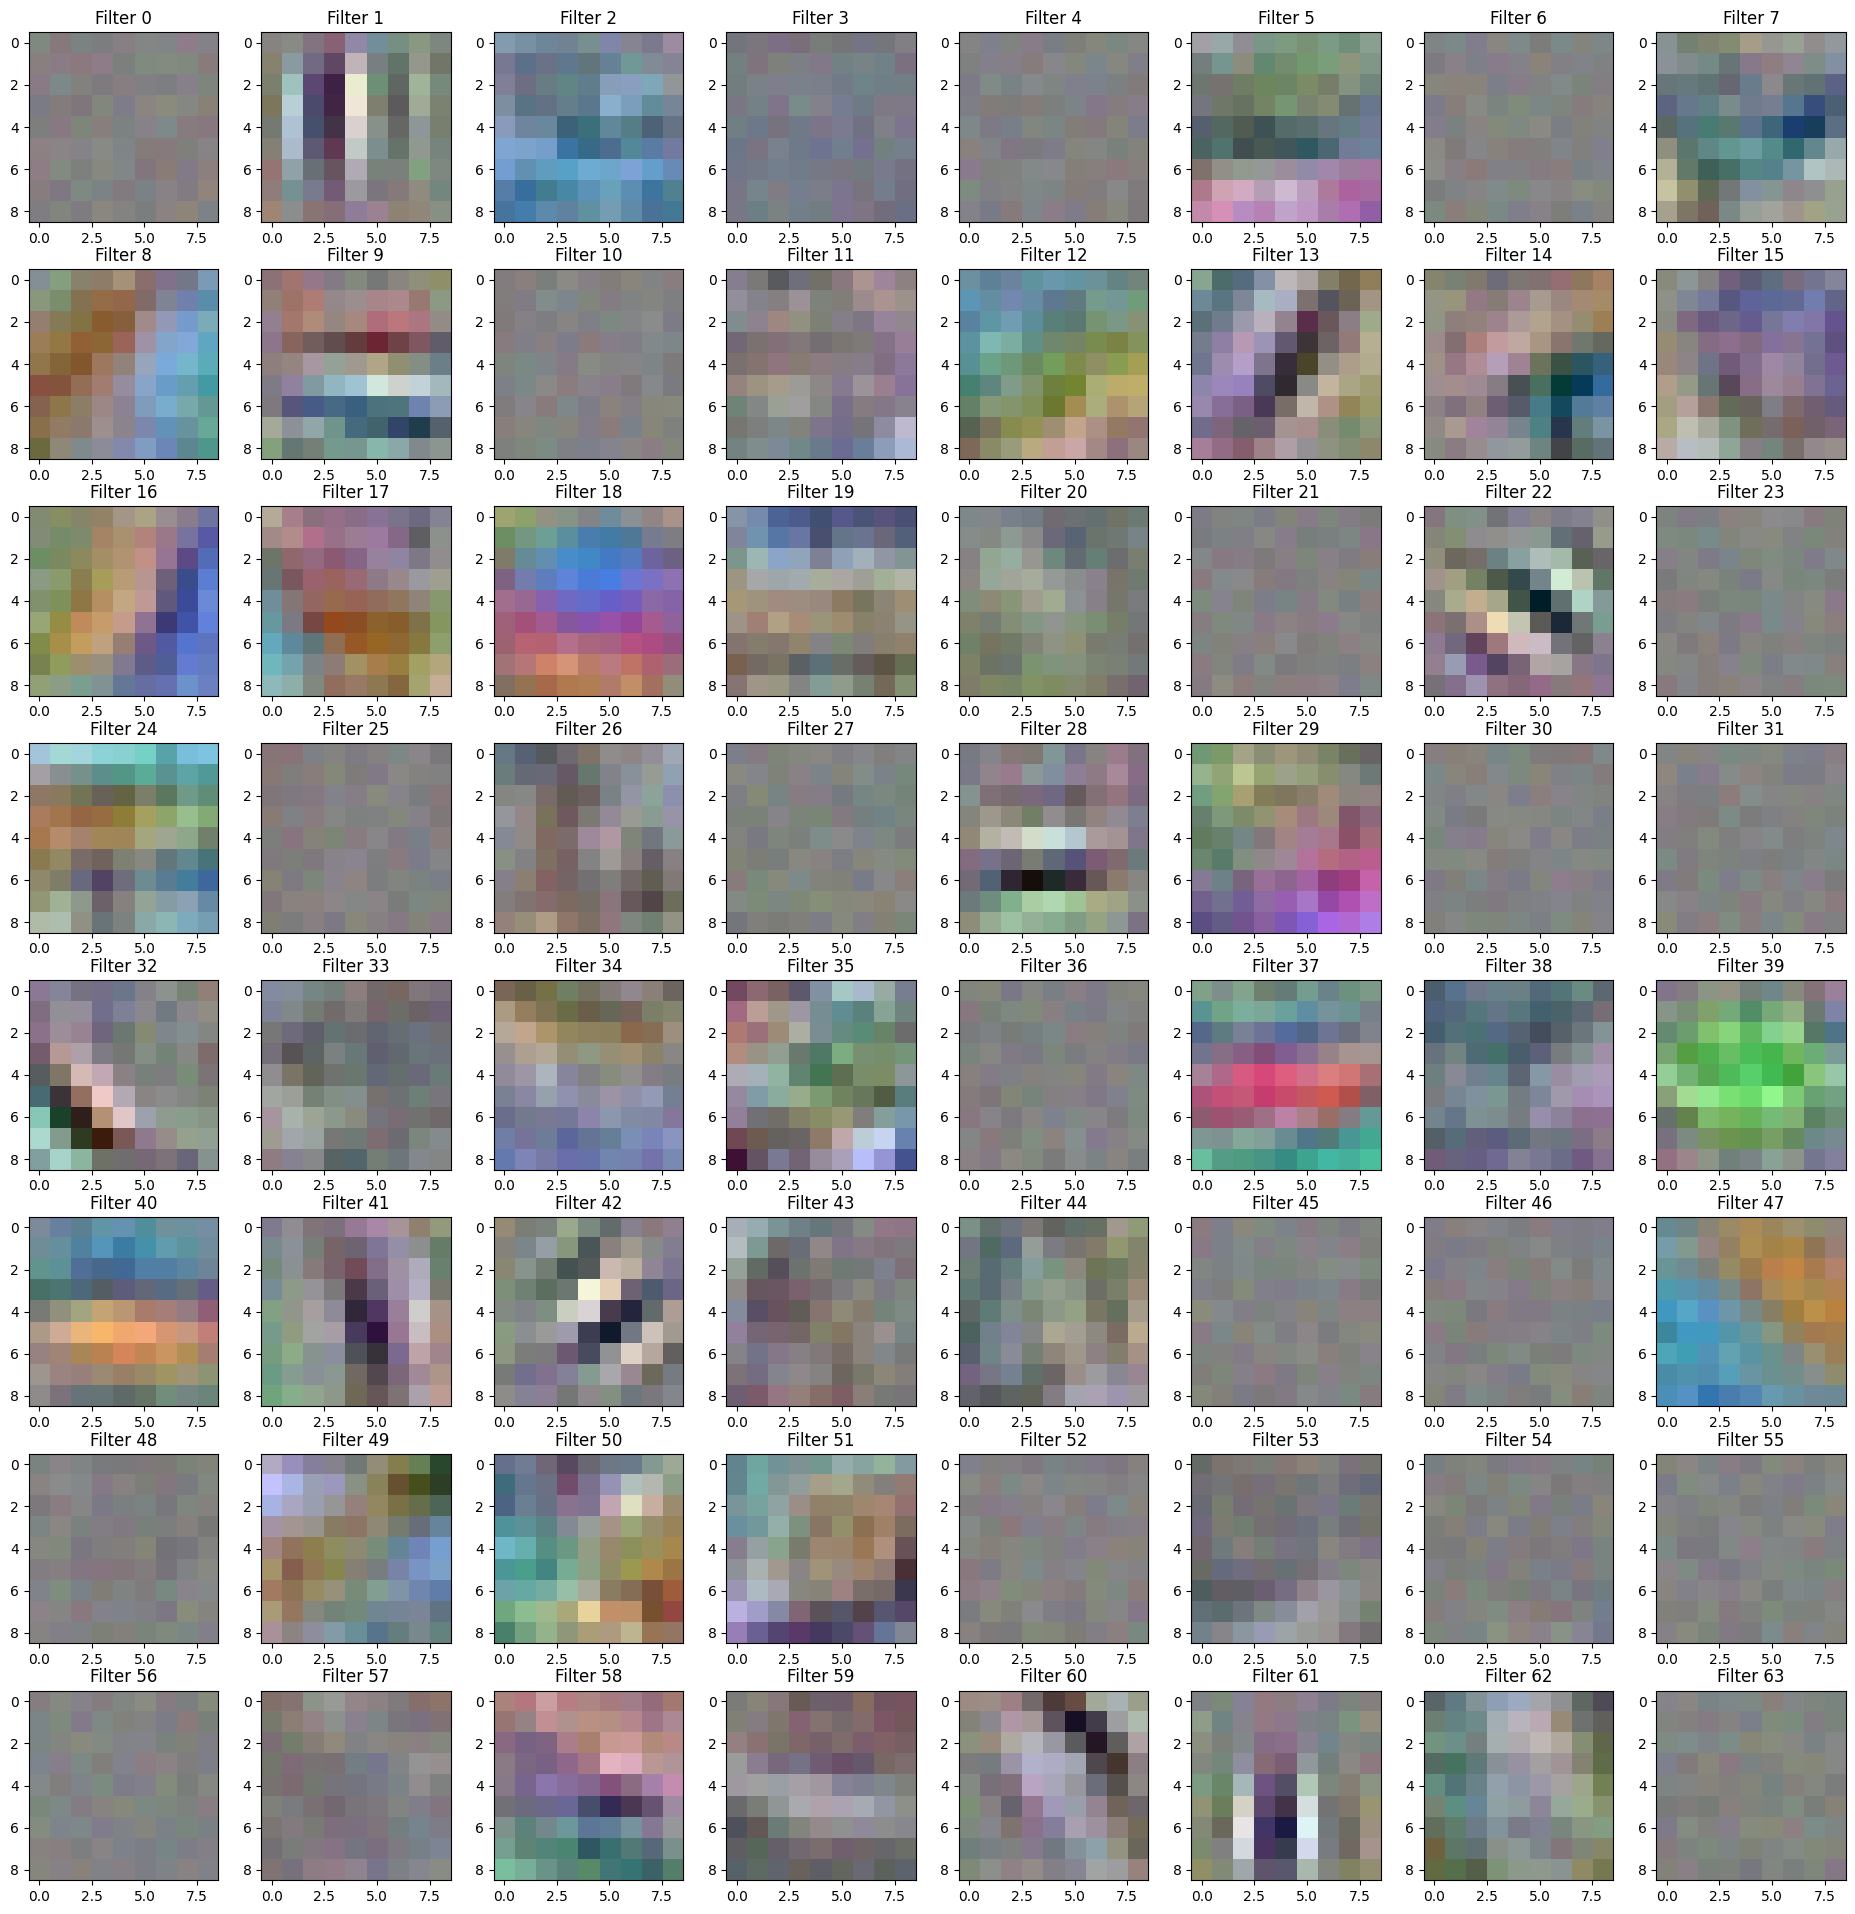

In [7]:
classifier.save_weights("cnn.weights.h5")

# 4. Visualize Convolutional Filters
cnn1_name = classifier.layers[1].name
W = classifier.get_layer(name=cnn1_name).get_weights()[0]
wshape = W.shape

scaler = MinMaxScaler()
scaler.fit(W.reshape(-1,1))
W = scaler.transform(W.reshape(-1,1))
W = W.reshape(wshape)

fig, axs = plt.subplots(8, 8, figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()

for i in range(W.shape[-1]):
    # reshape to a 3D (RGB) image shape and display
    h = np.reshape(W[:,:,:,i], (9,9,3))
    axs[i].imshow(h)
    axs[i].set_title('Filter ' + str(i))

plt.savefig("ch.12.cnn.full.filters.png", bbox_inches='tight', dpi=350)
plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📌 Sample training reviews (RNN):

Review 1:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5109 - loss: 0.6953 - val_accuracy: 0.5300 - val_loss: 0.6859
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6273 - loss: 0.6080 - val_accuracy: 0.6182 - val_loss: 0.6139
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7010 - loss: 0.4591 - val_accuracy: 0.6214 - val_loss: 0.6842
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7095 - loss: 0.4531 - val_accuracy: 0.5688 - val_loss: 0.7987
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7253 - loss: 0.3978 - val_accuracy: 0.5844 - val_loss: 0.8794
782/782 - 5s - 6ms/step - accuracy: 0.5767 - loss: 0.8939

✅ Test Accuracy (RNN): 0.5767
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

📊 Evaluation Metrics (RNN):
Accuracy     : 0.5767
Precision    : 0.6659
Recall       : 0.3078
F1-Score     : 0.4210
Specificity  : 0.8455
AUC-ROC      : 0.6300

Classification Report:
               precision    recall  f1-scor

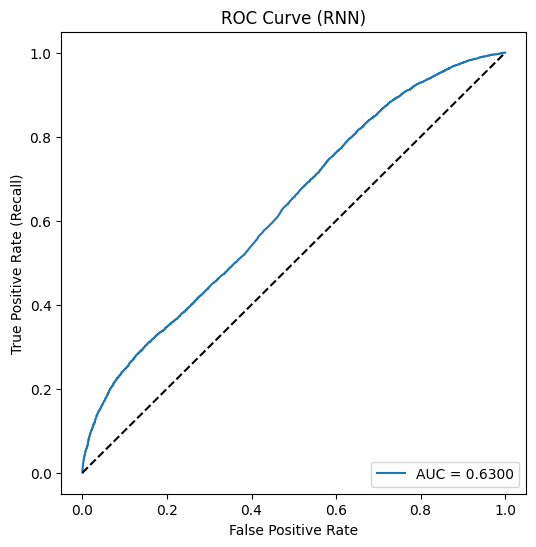

In [8]:
# week8_rnn_imdb.py
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# Parameters
vocab_size = 10000
maxlen = 200
embedding_dim = 128
rnn_units = 64
batch_size = 64
epochs = 5

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Decode sample reviews
word_index = imdb.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("\n📌 Sample training reviews (RNN):")
for i in range(3):
    print(f"\nReview {i+1}:")
    print(decode_review(x_train[i]))
    print("Label:", "Positive" if y_train[i] == 1 else "Negative")

# Preprocess
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post')

# Build RNN model
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=maxlen),
    layers.SimpleRNN(rnn_units),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy (RNN): {acc:.4f}")

# Extended evaluation
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n📊 Evaluation Metrics (RNN):")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC-ROC      : {auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (RNN)")
plt.legend(loc="lower right")
plt.show()


📌 Sample training reviews (LSTM):

Review 1:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.5701 - loss: 0.6621 - val_accuracy: 0.6278 - val_loss: 0.5996
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6921 - loss: 0.5507 - val_accuracy: 0.8208 - val_loss: 0.4457
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7322 - loss: 0.5109 - val_accuracy: 0.7516 - val_loss: 0.5199
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7886 - loss: 0.4409 - val_accuracy: 0.7870 - val_loss: 0.5006
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7831 - loss: 0.4610 - val_accuracy: 0.7358 - val_loss: 0.5810
782/782 - 5s - 7ms/step - accuracy: 0.7420 - loss: 0.5758

✅ Test Accuracy (LSTM): 0.7420
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step

📊 Evaluation Metrics (LSTM):
Accuracy     : 0.7420
Precision    : 0.7215
Recall       : 0.7882
F1-Score     : 0.7534
Specificity  : 0.6958
AUC-ROC      : 0.8144

Classification Report:
               precision    recall  f1-sco

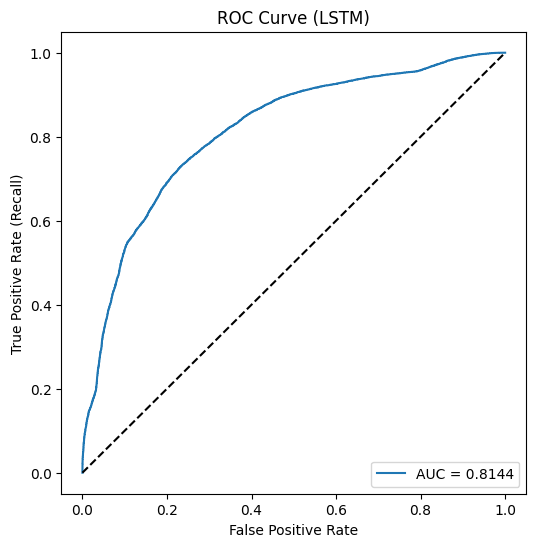

In [9]:
# week9
#_lstm_imdb.py
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences  # FIXED: Updated path for Keras 3
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report  # FIXED: Added missing import
)
import matplotlib.pyplot as plt

# Parameters
vocab_size = 10000
maxlen = 200
embedding_dim = 128
lstm_units = 64
batch_size = 64
epochs = 5

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Decode sample reviews
word_index = imdb.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("\n📌 Sample training reviews (LSTM):")
for i in range(3):
    print(f"\nReview {i+1}:")
    print(decode_review(x_train[i]))
    print("Label:", "Positive" if y_train[i] == 1 else "Negative")

# Preprocess
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post')

# Build LSTM model
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim), # FIXED: Removed deprecated input_length
    layers.LSTM(lstm_units),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy (LSTM): {acc:.4f}")

# Extended evaluation
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n📊 Evaluation Metrics (LSTM):")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC-ROC      : {auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (LSTM)")
plt.legend(loc="lower right")
plt.show()


📌 Sample training reviews (BiLSTM):

Review 1:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.7352 - loss: 0.5174 - val_accuracy: 0.8448 - val_loss: 0.3751
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8963 - loss: 0.2784 - val_accuracy: 0.8712 - val_loss: 0.3096
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9305 - loss: 0.1935 - val_accuracy: 0.8492 - val_loss: 0.3756
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9496 - loss: 0.1440 - val_accuracy: 0.8628 - val_loss: 0.3858
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9681 - loss: 0.0953 - val_accuracy: 0.8410 - val_loss: 0.4512
782/782 - 7s - 9ms/step - accuracy: 0.8375 - loss: 0.4717

✅ Test Accuracy (BiLSTM): 0.8375
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step

📊 Evaluation Metrics (BiLSTM):
Accuracy     : 0.8375
Precision    : 0.8034
Recall       : 0.8938
F1-Score     : 0.8462
Specificity  : 0.7813
AUC-ROC      : 0.9143

Classification Report:
               precision    recall  

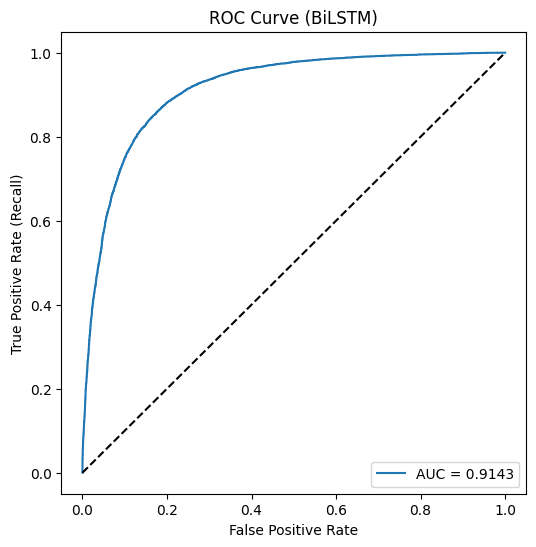

In [10]:
# week10
#_bilstm_imdb.py
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences  # FIXED: Updated path for Keras 3
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report  # FIXED: Added missing import
)
import matplotlib.pyplot as plt

# Parameters
vocab_size = 10000
maxlen = 200
embedding_dim = 128
lstm_units = 64
batch_size = 64
epochs = 5

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Decode sample reviews
word_index = imdb.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("\n📌 Sample training reviews (BiLSTM):")
for i in range(3):
    print(f"\nReview {i+1}:")
    print(decode_review(x_train[i]))
    print("Label:", "Positive" if y_train[i] == 1 else "Negative")

# Preprocess
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post')

# Build BiLSTM model
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim), # FIXED: Removed deprecated input_length
    layers.Bidirectional(layers.LSTM(lstm_units)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy (BiLSTM): {acc:.4f}")

# Extended evaluation
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n📊 Evaluation Metrics (BiLSTM):")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC-ROC      : {auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (BiLSTM)")
plt.legend(loc="lower right")
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.8556 | G Loss: 1.3167
Epoch 200 | D Loss: 3.3999 | G Loss: 0.0348
Epoch 400 | D Loss: 3.7641 | G Loss: 0.0178
Epoch 600 | D Loss: 3.9416 | G Loss: 0.0121
Epoch 800 | D Loss: 4.0450 | G Loss: 0.0092


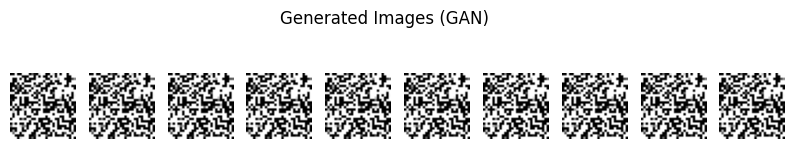

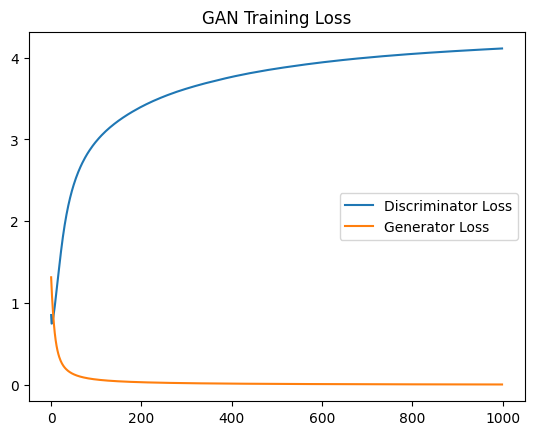

In [11]:
# week11
#_gan_mnist.py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load dataset (using MNIST as proxy for medical grayscale images)
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_train = x_train.reshape(-1, 784)

# Parameters
latent_dim = 100
batch_size = 128
epochs = 1000

# =========================
# Generator
# =========================
generator = tf.keras.Sequential([
    layers.Input(shape=(latent_dim,)),  # FIXED: Replaced deprecated input_dim
    layers.Dense(128, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(784, activation='sigmoid')
])

# =========================
# Discriminator
# =========================
discriminator = tf.keras.Sequential([
    layers.Input(shape=(784,)),  # FIXED: Replaced deprecated input_dim
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# FIXED: Added the missing loss function that was causing a syntax error below
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Freeze discriminator for GAN
discriminator.trainable = False

# GAN Model
gan_input = layers.Input(shape=(latent_dim,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

# FIXED: Removed the floating `loss='binary_crossentropy',` syntax error from here
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# Training
# =========================
d_losses = []
g_losses = []

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

# =========================
# Generate Images
# =========================
noise = np.random.normal(0, 1, (10, latent_dim))
generated_images = generator.predict(noise, verbose=0)

# Plot generated images
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Images (GAN)")
plt.show()

# =========================
# Plot Loss
# =========================
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.legend()
plt.title("GAN Training Loss")
plt.show()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0579 - val_loss: 0.0312
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0249 - val_loss: 0.0196
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0179 - val_loss: 0.0155
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0146 - val_loss: 0.0130
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0126 - val_loss: 0.0115
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0112 - val_loss: 0.0103
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0102 - val_loss: 0.0097
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0095 - val_loss: 0.0088
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084 - val_loss: 0.0080
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Reconstruction MSE: 0.00798309157051764


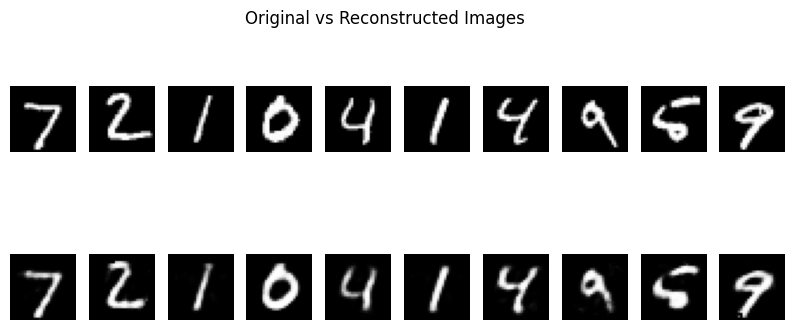

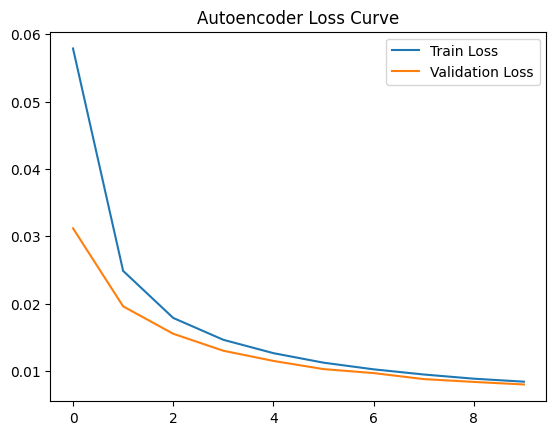

In [12]:
# week12_autoencoder_mnist.py
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Load dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# =========================
# Build Autoencoder
# =========================
input_dim = 784
encoding_dim = 64
input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = models.Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# =========================
# Train
# =========================
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# =========================
# Reconstruction
# =========================
decoded_imgs = autoencoder.predict(x_test)

# =========================
# MSE Evaluation
# =========================
mse = mean_squared_error(x_test, decoded_imgs)
print("\nReconstruction MSE:", mse)

# =========================
# Visualization
# =========================
n = 10
plt.figure(figsize=(10, 4))

# Original
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

# Reconstructed
for i in range(n):
    plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images")
plt.show()

# =========================
# Loss Curve
# =========================
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Loss Curve")
plt.show()